Title: LEE_Results_Analysis.ipynb

Purpose: Look at the found LEE Events

Author: Onno Nennecke on 16.07.2025 Modified: 11.09.2025

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- Plots: LEE_Event_yearly_distr, LEE_durations_comparison
    - These files lie here: /home/onennecke/Code/Figures/

In [15]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import dask.array as da

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

import scipy.ndimage as ndimage
from scipy.stats import norm
from scipy import stats
import os
import glob

from datetime import datetime

### Read LEE data

In [16]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


In [17]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]

In [18]:
LEE_dat['ESM'].unique()

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5_week',
       'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0',
       'TaiESM1', 'UKESM1-0-LL'], dtype=object)

---

### Count

In [19]:
# Pure CMIP6 data
LEE_dat_CMIP = LEE_dat[LEE_dat['ESM'] != 'ERA5_week']
LEE_7_CMIP = LEE_7[LEE_7['ESM'] != 'ERA5_week']
LEE_14_CMIP = LEE_14[LEE_14['ESM'] != 'ERA5_week']
LEE_vl_CMIP = LEE_vl[LEE_vl['ESM'] != 'ERA5_week']

In [20]:
print(np.count_nonzero(LEE_dat_CMIP['duration']))
print(np.count_nonzero(LEE_7_CMIP['duration']))
print(np.count_nonzero(LEE_14_CMIP['duration']))
print(np.count_nonzero(LEE_vl_CMIP['duration']))

18067
1122
255
9135


In [21]:
# Pure ERA5 data
LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]

In [22]:
print(np.count_nonzero(LEE_dat_ERA5['duration']))
print(np.count_nonzero(LEE_7_ERA5['duration']))
print(np.count_nonzero(LEE_14_ERA5['duration']))
print(np.count_nonzero(LEE_vl_ERA5['duration']))

183
10
2
92


In [23]:
# Calculate factors between CMIP6 and ERA5 for # of events
factor_1 = np.count_nonzero(LEE_dat_CMIP['duration']) / np.count_nonzero(LEE_dat_ERA5['duration'])
factor_7 = np.count_nonzero(LEE_7_CMIP['duration']) / np.count_nonzero(LEE_7_ERA5['duration'])
factor_14 = np.count_nonzero(LEE_14_CMIP['duration']) / np.count_nonzero(LEE_14_ERA5['duration'])
factor_vl = np.count_nonzero(LEE_vl_CMIP['duration']) / np.count_nonzero(LEE_vl_ERA5['duration'])

print(f"Factor for 1-day events: {factor_1:.2f}")
print(f"Factor for 7-day events: {factor_7:.2f}")
print(f"Factor for 14-day events: {factor_14:.2f}")
print(f"Factor for variable length events: {factor_vl:.2f}")

print(f'Average Number of CMIP event days for 1-day: {np.count_nonzero(LEE_dat_CMIP['duration'])/99:.2f} days')
print(f'Average Number of CMIP event days for 7-day: {np.count_nonzero(LEE_7_CMIP['duration'])/99:.2f} days')
print(f'Average Number of CMIP event days for 14-day: {np.count_nonzero(LEE_14_CMIP['duration'])/99:.2f} days')
print(f'Average Number of CMIP event days for variable length: {np.count_nonzero(LEE_vl_CMIP['duration'])/99:.2f} days')

print(f'Average Number of ERA5 event days for 1-day: {np.count_nonzero(LEE_dat_ERA5['duration']):.2f} days')
print(f'Average Number of ERA5 event days for 7-day: {np.count_nonzero(LEE_7_ERA5['duration']):.2f} days')
print(f'Average Number of ERA5 event days for 14-day: {np.count_nonzero(LEE_14_ERA5['duration']):.2f} days')
print(f'Average Number of ERA5 event days for variable length: {np.count_nonzero(LEE_vl_ERA5['duration']):.2f} days')

Factor for 1-day events: 98.73
Factor for 7-day events: 112.20
Factor for 14-day events: 127.50
Factor for variable length events: 99.29
Average Number of CMIP event days for 1-day: 182.49 days
Average Number of CMIP event days for 7-day: 11.33 days
Average Number of CMIP event days for 14-day: 2.58 days
Average Number of CMIP event days for variable length: 92.27 days
Average Number of ERA5 event days for 1-day: 183.00 days
Average Number of ERA5 event days for 7-day: 10.00 days
Average Number of ERA5 event days for 14-day: 2.00 days
Average Number of ERA5 event days for variable length: 92.00 days


In [24]:
print(f'Max ERA5 RL cum: {max(LEE_dat_ERA5['RL_cumulative']):.2f} GWh')
print(f'Max CMIP RL cum: {max(LEE_dat_CMIP['RL_cumulative']):.2f} GWh')
# print(f'CMIP is on average: {max(LEE_dat_CMIP['RL_cumulative']) / max(LEE_dat_ERA5['RL_cumulative']):.2f} times higher than ERA5')
print(f'Most extreme CMIP event is: {(max(LEE_dat_CMIP['RL_cumulative']) - max(LEE_dat_ERA5['RL_cumulative'])) / max(LEE_dat_ERA5['RL_cumulative']) * 100:.2f}% higher than ERA5')
print(f'The difference are: {max(LEE_dat_CMIP['RL_cumulative']) - max(LEE_dat_ERA5['RL_cumulative']):.2f} GWh')
print('---')

print(f'Max ERA5 RL cum: {max(LEE_7_ERA5['RL_cumulative']):.2f} GWh')
print(f'Max CMIP RL cum: {max(LEE_7_CMIP['RL_cumulative']):.2f} GWh')
# print(f'CMIP is on average: {max(LEE_7_CMIP['RL_cumulative']) / max(LEE_7_ERA5['RL_cumulative']):.2f} times higher than ERA5')
print(f'Most extreme CMIP event is: {(max(LEE_7_CMIP['RL_cumulative']) - max(LEE_7_ERA5['RL_cumulative'])) / max(LEE_7_ERA5['RL_cumulative']) * 100:.2f}% higher than ERA5')
print(f'The difference are: {max(LEE_7_CMIP['RL_cumulative']) - max(LEE_7_ERA5['RL_cumulative']):.2f} GWh')
print('---')

print(f'Max ERA5 RL cum: {max(LEE_14_ERA5['RL_cumulative']):.2f} GWh')
print(f'Max CMIP RL cum: {max(LEE_14_CMIP['RL_cumulative']):.2f} GWh')
# print(f'CMIP is on average: {max(LEE_14_CMIP['RL_cumulative']) / max(LEE_14_ERA5['RL_cumulative']):.2f} times higher than ERA5')
print(f'Most extreme CMIP event is: {(max(LEE_14_CMIP['RL_cumulative']) - max(LEE_14_ERA5['RL_cumulative'])) / max(LEE_14_ERA5['RL_cumulative']) * 100:.2f}% higher than ERA5')
print(f'The difference are: {max(LEE_14_CMIP['RL_cumulative']) - max(LEE_14_ERA5['RL_cumulative']):.2f} GWh')
print('---')

print(f'Max ERA5 RL cum: {max(LEE_vl_ERA5['RL_cumulative']):.2f} GWh')
print(f'Max CMIP RL cum: {max(LEE_vl_CMIP['RL_cumulative']):.2f} GWh')
# print(f'CMIP is on average: {max(LEE_vl_CMIP['RL_cumulative']) / max(LEE_vl_ERA5['RL_cumulative']):.2f} times higher than ERA5')
print(f'Most extreme CMIP event is: {(max(LEE_vl_CMIP['RL_cumulative']) - max(LEE_vl_ERA5['RL_cumulative'])) / max(LEE_vl_ERA5['RL_cumulative']) * 100:.2f}% higher than ERA5')
print(f'The difference are: {max(LEE_vl_CMIP['RL_cumulative']) - max(LEE_vl_ERA5['RL_cumulative']):.2f} GWh')
print('---')

print(f'Max ERA5 duration: {max(LEE_vl_ERA5['duration']):.2f} days')
print(f'Max CMIP duration: {max(LEE_vl_CMIP['duration']):.2f} days')
# print(f'CMIP is on average: {max(LEE_vl_CMIP['duration']) / max(LEE_vl_ERA5['duration']):.2f} times higher than ERA5')
print(f'Most extreme CMIP event is: {(max(LEE_vl_CMIP['duration']) - max(LEE_vl_ERA5['duration'])) / max(LEE_vl_ERA5['duration']) * 100:.2f}% higher than ERA5')
print(f'The difference are: {max(LEE_vl_CMIP['duration']) - max(LEE_vl_ERA5['duration']):.2f} days')
print('---')


Max ERA5 RL cum: 1554.15 GWh
Max CMIP RL cum: 1654.91 GWh
Most extreme CMIP event is: 6.48% higher than ERA5
The difference are: 100.76 GWh
---
Max ERA5 RL cum: 10444.57 GWh
Max CMIP RL cum: 11359.88 GWh
Most extreme CMIP event is: 8.76% higher than ERA5
The difference are: 915.31 GWh
---
Max ERA5 RL cum: 19897.36 GWh
Max CMIP RL cum: 22001.67 GWh
Most extreme CMIP event is: 10.58% higher than ERA5
The difference are: 2104.30 GWh
---
Max ERA5 RL cum: 13340.26 GWh
Max CMIP RL cum: 33473.32 GWh
Most extreme CMIP event is: 150.92% higher than ERA5
The difference are: 20133.06 GWh
---
Max ERA5 duration: 9.00 days
Max CMIP duration: 23.00 days
Most extreme CMIP event is: 155.56% higher than ERA5
The difference are: 14.00 days
---


In [25]:
LEE_dat_ERA5['RL_mean']

9496    1476.578114
9497    1492.586549
9498    1467.345044
9499    1439.511499
9500    1497.249011
           ...     
9674    1491.259356
9675    1473.156796
9676    1443.400458
9677    1486.131628
9678    1483.247560
Name: RL_mean, Length: 183, dtype: float64

In [26]:
print(f'Mean RL_mean 1-day: {np.mean(LEE_dat['RL_mean']):.2f} GWh')
print(f'Mean RL_mean 7-day: {np.mean(LEE_7['RL_mean']):.2f} GWh')
print(f'Mean RL_mean 14-day: {np.mean(LEE_14['RL_mean']):.2f} GWh')
print(f'Mean RL_mean variable-length: {np.mean(LEE_vl['RL_mean']):.2f} GWh')
print('---')

print(f'ERA5 Mean RL_mean 1-day: {np.mean(LEE_dat_ERA5['RL_mean']):.2f} GWh')
print(f'CMIP Mean RL_mean 1-day: {np.mean(LEE_dat_CMIP['RL_mean']):.2f} GWh')
print('---')

print(f'ERA5 Mean RL_mean 7-day: {np.mean(LEE_7_ERA5['RL_mean']):.2f} GWh')
print(f'CMIP Mean RL_mean 7-day: {np.mean(LEE_7_CMIP['RL_mean']):.2f} GWh')
print('---')

print(f'ERA5 Mean RL_mean 14-day: {np.mean(LEE_14_ERA5['RL_mean']):.2f} GWh')
print(f'CMIP Mean RL_mean 14-day: {np.mean(LEE_14_CMIP['RL_mean']):.2f} GWh')
print('---')

print(f'Mean ERA5 RL_mean VL: {np.mean(LEE_vl_ERA5['RL_mean']):.2f} GWh')
print(f'Mean CMIP RL_mean VL: {np.mean(LEE_vl_CMIP['RL_mean']):.2f} GWh')
print('---')

Mean RL_mean 1-day: 1455.83 GWh
Mean RL_mean 7-day: 1441.57 GWh
Mean RL_mean 14-day: 1432.40 GWh
Mean RL_mean variable-length: 1445.90 GWh
---
ERA5 Mean RL_mean 1-day: 1450.95 GWh
CMIP Mean RL_mean 1-day: 1455.88 GWh
---
ERA5 Mean RL_mean 7-day: 1444.64 GWh
CMIP Mean RL_mean 7-day: 1441.54 GWh
---
ERA5 Mean RL_mean 14-day: 1420.38 GWh
CMIP Mean RL_mean 14-day: 1432.50 GWh
---
Mean ERA5 RL_mean VL: 1444.29 GWh
Mean CMIP RL_mean VL: 1445.91 GWh
---


In [27]:
print('Max ERA5 VL duration:', max(LEE_vl_ERA5['duration']))
print('Median VL duration all:', np.median(LEE_vl['duration']))
print('Mean VL duration all:', np.mean(LEE_vl['duration']))

print('RL cum case study ERA5:', LEE_dat_ERA5[173:174]['RL_cumulative'].values[0])

Max ERA5 VL duration: 9
Median VL duration all: 1.0
Mean VL duration all: 1.97789097214696
RL cum case study ERA5: 1427.7965993926362


### Cumulative RL Distribution

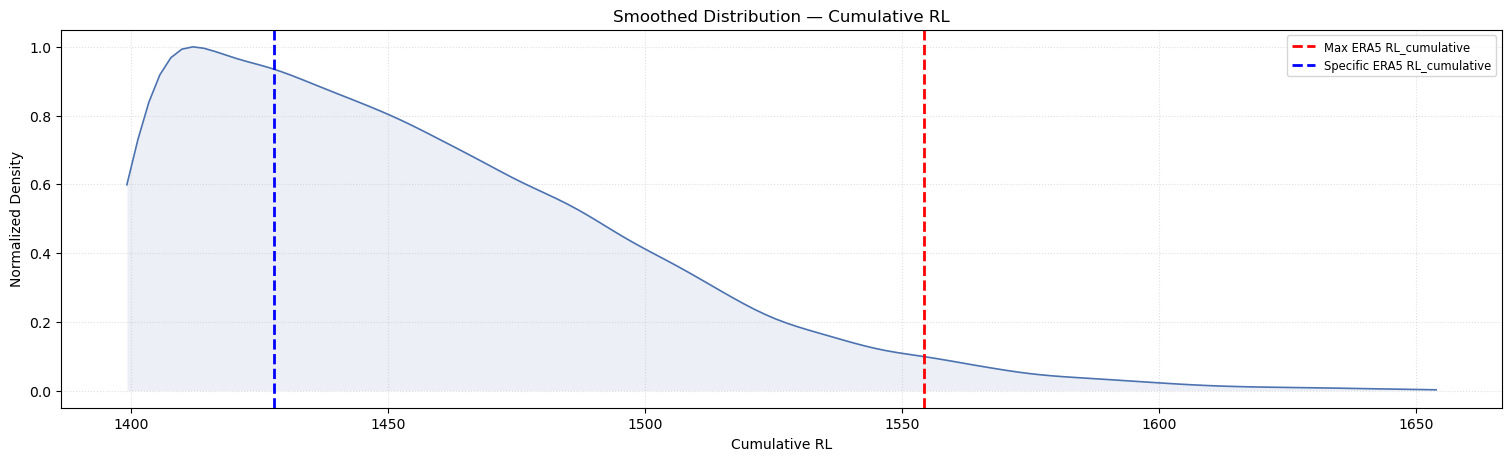

In [28]:
# variables and appearance
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (15,4.5)  # figure size
color_all = '#4c72b0'
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)  # 3 subplots in a row

# for ax, (col, pretty) in zip(axes, columns):
a = LEE_dat['RL_cumulative'].values  # all data array

# common bin edges spanning min..max across all 3 sets so curves align
edges = np.linspace(a.min(), a.max(), bins+1)  # bin edges
centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

# histogram counts (density=False -> raw counts) computed on the same edges
ca, _ = np.histogram(a, bins=edges, density=False)  # counts for all

# smooth counts by convolving with the gaussian kernel
sa = np.convolve(ca, kernel, mode='same')  # smoothed all

# normalize so the largest peak among the three equals 1 (same as your original)
peak = max(sa.max(), 1e-12)  # avoid division by zero
sa /= peak  # normalized all

# plotting curves + fills
ax.plot(centers, sa, lw=lw, color=color_all)  # all curve
ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

# Add a vertical marker line at the most common RL_cumulative value
ax.axvline(max(LEE_dat_ERA5['RL_cumulative']), color='red', linestyle='--', linewidth=2, label='Max ERA5 RL_cumulative')
ax.axvline(LEE_dat_ERA5[173:174]['RL_cumulative'].values[0], color='blue', linestyle='--', linewidth=2, label='Specific ERA5 RL_cumulative')

# labels and styling
ax.set_title('Smoothed Distribution — Cumulative RL')  # subplot title
ax.set_xlabel('Cumulative RL')  # x label
ax.set_ylabel('Normalized Density')  # y label
ax.grid(True, linestyle=':', alpha=0.4)  # grid
ax.legend(fontsize='small')  # legend

plt.show()  # display


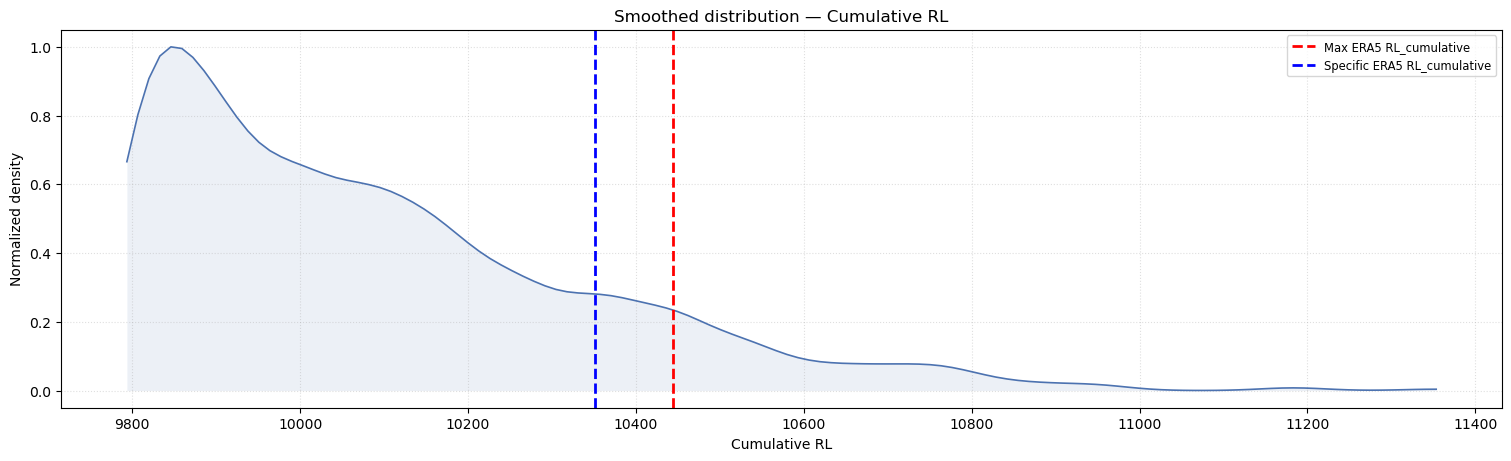

In [29]:
# variables and appearance
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (15,4.5)  # figure size
color_all = '#4c72b0'
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)  # 3 subplots in a row

# for ax, (col, pretty) in zip(axes, columns):
a = LEE_7['RL_cumulative'].values  # all data array

# common bin edges spanning min..max across all 3 sets so curves align
edges = np.linspace(a.min(), a.max(), bins+1)  # bin edges
centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

# histogram counts (density=False -> raw counts) computed on the same edges
ca, _ = np.histogram(a, bins=edges, density=False)  # counts for all

# smooth counts by convolving with the gaussian kernel
sa = np.convolve(ca, kernel, mode='same')  # smoothed all

# normalize so the largest peak among the three equals 1 (same as your original)
peak = max(sa.max(), 1e-12)  # avoid division by zero
sa /= peak  # normalized all

# plotting curves + fills
ax.plot(centers, sa, lw=lw, color=color_all)  # all curve
ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

# Add a vertical marker line at the most common RL_cumulative value
ax.axvline(max(LEE_7_ERA5['RL_cumulative']), color='red', linestyle='--', linewidth=2, label='Max ERA5 RL_cumulative')
ax.axvline(LEE_7_ERA5[3:4]['RL_cumulative'].values[0], color='blue', linestyle='--', linewidth=2, label='Specific ERA5 RL_cumulative')

# labels and styling
ax.set_title('Smoothed distribution — Cumulative RL')  # subplot title
ax.set_xlabel('Cumulative RL')  # x label
ax.set_ylabel('Normalized density')  # y label
ax.grid(True, linestyle=':', alpha=0.4)  # grid
ax.legend(fontsize='small')  # legend

plt.show()  # display


In [30]:
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1423.036821,1423.036821,0.0,1423.036821,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.904166,1437.904166,0.0,1437.904166,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.128472,1479.128472,0.0,1479.128472,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.444224,1469.444224,0.0,1469.444224,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.203439,1484.203439,0.0,1484.203439,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18509,2024-11-11,2024-11-11,2024-11-11,3599,3599,3599,1,1421.402262,1421.402262,0.0,1421.402262,18510,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,315
18510,2024-11-14,2024-11-14,2024-11-14,3602,3602,3602,1,1412.689224,1412.689224,0.0,1412.689224,18511,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,318
18511,2024-11-16,2024-11-16,2024-11-16,3604,3604,3604,1,1468.658163,1468.658163,0.0,1468.658163,18512,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320
18512,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1470.535544,1470.535544,0.0,1470.535544,18513,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,354


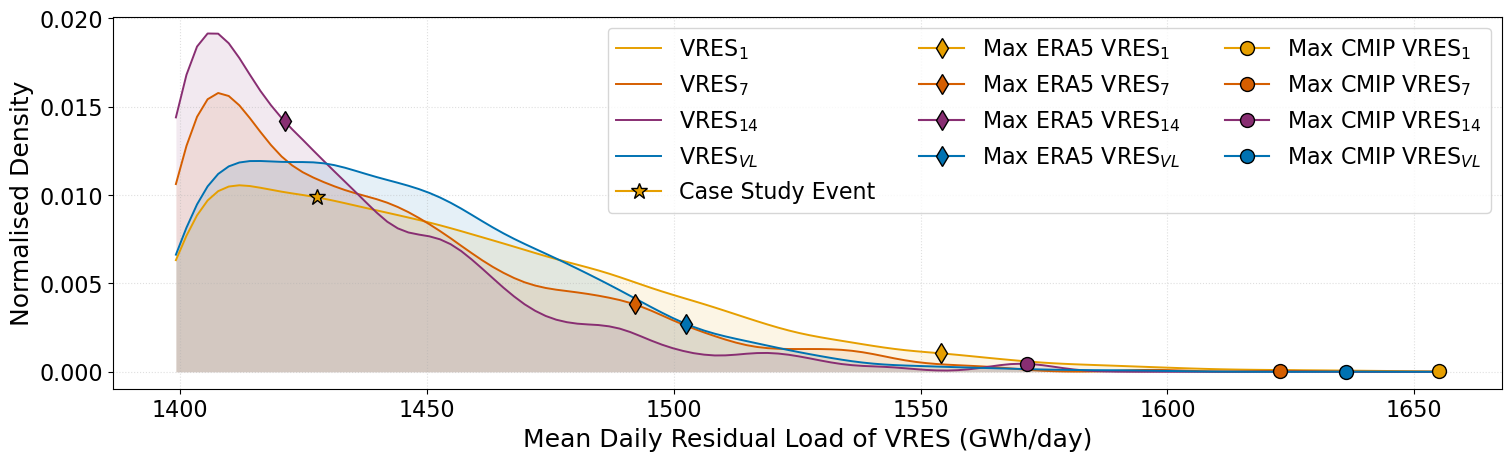

In [31]:
mpl.rcParams.update({
    'font.size': 16+2,
    'axes.titlesize': 18+2,
    'axes.labelsize': 16+2,
    'xtick.labelsize': 14+2,
    'ytick.labelsize': 14+2,
    'legend.fontsize': 16,
    'figure.titlesize': 18+2,
})

# variables and appearance
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (15,4.5)  # figure size

color_1 = '#E69F00'
color_7 = '#D55E00'
color_14 = '#882E72'
color_vl = '#0072B2'

lw = 1.4  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)  

# for ax, (col, pretty) in zip(axes, columns):
a = LEE_dat['RL_mean'].values  # all data array
b = LEE_7['RL_mean'].values  # all data array
c = LEE_14['RL_mean'].values  # all data array
d = LEE_vl['RL_mean'].values  # all data array

# common bin edges spanning min..max across all 4 sets so curves align
edges = np.linspace(min(a.min(), b.min(), c.min(), d.min()), max(a.max(), b.max(), c.max(), d.max()), bins+1)  # bin edges
centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

# edges_a = np.linspace(a.min(), a.max(), bins+1)
# edges_b = np.linspace(b.min(), b.max(), bins+1)
# edges_c = np.linspace(c.min(), c.max(), bins+1)
# edges_d = np.linspace(d.min(), d.max(), bins+1)

# centers_a = (edges_a[:-1] + edges_a[1:]) / 2.0  # bin centers
# centers_b = (edges_b[:-1] + edges_b[1:]) / 2.0  # bin centers
# centers_c = (edges_c[:-1] + edges_c[1:]) / 2.0  # bin centers
# centers_d = (edges_d[:-1] + edges_d[1:]) / 2.0  # bin centers

# # histogram counts (density=False -> raw counts) computed on the same edges
# ca, _ = np.histogram(a, bins=edges_a, density=True)  # counts for all
# cb, _ = np.histogram(b, bins=edges_b, density=True)  # counts for 7
# cc, _ = np.histogram(c, bins=edges_c, density=True)  # counts for 14
# cd, _ = np.histogram(d, bins=edges_d, density=True)  # counts for VL

ca, _ = np.histogram(a, bins=edges, density=True)  # counts for all
cb, _ = np.histogram(b, bins=edges, density=True)  # counts for 7
cc, _ = np.histogram(c, bins=edges, density=True)  # counts for 14
cd, _ = np.histogram(d, bins=edges, density=True)  # counts for VL

# smooth counts by convolving with the gaussian kernel
sa = np.convolve(ca, kernel, mode='same')  # smoothed all
sb = np.convolve(cb, kernel, mode='same')  # smoothed 7
sc = np.convolve(cc, kernel, mode='same')  # smoothed 14
sd = np.convolve(cd, kernel, mode='same')  # smoothed VL

# plotting curves + fills
# ax.plot(centers_a, sa, lw=lw, color=color_1, label='1-day')  # all curve
# ax.plot(centers_b, sb, lw=lw, color=color_7, label='7-day')  # 7 curve
# ax.plot(centers_c, sc, lw=lw, color=color_14, label='14-day')  # 14 curve
# ax.plot(centers_d, sd, lw=lw, color=color_vl, label='Variable Length')  # VL curve

# ax.fill_between(centers_a, sa, 0, color=color_1, alpha=fill_alpha, linewidth=0)  # fill all
# ax.fill_between(centers_b, sb, 0, color=color_7, alpha=fill_alpha, linewidth=0)  # fill 7
# ax.fill_between(centers_c, sc, 0, color=color_14, alpha=fill_alpha, linewidth=0)  # fill 14
# ax.fill_between(centers_d, sd, 0, color=color_vl, alpha=fill_alpha, linewidth=0)  # fill VL

ax.plot(centers, sa, lw=lw, color=color_1, label=r'$\mathrm{VRES}_{1}$')  # all curve
ax.plot(centers, sb, lw=lw, color=color_7, label=r'$\mathrm{VRES}_{7}$')  # 7 curve
ax.plot(centers, sc, lw=lw, color=color_14, label=r'$\mathrm{VRES}_{14}$')  # 14 curve
ax.plot(centers, sd, lw=lw, color=color_vl, label=r'$\mathrm{VRES}_{VL}$')  # VL curve

ax.fill_between(centers, sa, 0, color=color_1, alpha=fill_alpha, linewidth=0)  # fill all
ax.fill_between(centers, sb, 0, color=color_7, alpha=fill_alpha, linewidth=0)  # fill 7
ax.fill_between(centers, sc, 0, color=color_14, alpha=fill_alpha, linewidth=0)  # fill 14
ax.fill_between(centers, sd, 0, color=color_vl, alpha=fill_alpha, linewidth=0)  # fill VL

# --- Replace vertical lines with curve markers --------------------------------
# Get marker positions (x) for each curve
x1 = max(LEE_dat_ERA5['RL_mean'])
x7 = max(LEE_7_ERA5['RL_mean'])
x14 = max(LEE_14_ERA5['RL_mean'])
xvl = max(LEE_vl_ERA5['RL_mean'])
x_case = LEE_dat_ERA5[173:174]['RL_mean'].values[0]

x1_CMIP = max(LEE_dat_CMIP['RL_mean'])
x7_CMIP = max(LEE_7_CMIP['RL_mean'])
x14_CMIP = max(LEE_14_CMIP['RL_mean'])
xvl_CMIP = max(LEE_vl_CMIP['RL_mean'])


# Helper to find y-value at a given x for a curve (linear interpolation)
def interp_y(x_points, y_points, x_target):
    return np.interp(x_target, x_points, y_points)

# Corresponding y values
# y1 = interp_y(centers_a, sa, x1)
# y7 = interp_y(centers_b, sb, x7)
# y14 = interp_y(centers_c, sc, x14)
# yvl = interp_y(centers_d, sd, xvl)
# y_case = interp_y(centers_a, sa, x_case)  # or whichever curve fits your case study

y1 = interp_y(centers, sa, x1)
y7 = interp_y(centers, sb, x7)
y14 = interp_y(centers, sc, x14)
yvl = interp_y(centers, sd, xvl)
y_case = interp_y(centers, sa, x_case)  # or whichever curve fits your case study

# Plot markers instead of vertical lines
ax.plot(x_case, y_case, marker='*', color=color_1, markersize=12,
        markeredgecolor='k', label='Case Study Event')
ax.plot(x1, y1, marker='d', color=color_1, markersize=10,
        markeredgecolor='k', label=r'Max ERA5 $\mathrm{VRES}_{1}$')
ax.plot(x7, y7, marker='d', color=color_7, markersize=10,
        markeredgecolor='k', label=r'Max ERA5 $\mathrm{VRES}_{7}$')
ax.plot(x14, y14, marker='d', color=color_14, markersize=10,
        markeredgecolor='k', label=r'Max ERA5 $\mathrm{VRES}_{14}$')
ax.plot(xvl, yvl, marker='d', color=color_vl, markersize=10,
        markeredgecolor='k', label=r'Max ERA5 $\mathrm{VRES}_{VL}$')

# ------------------------------------------------------------------------------

# Corresponding y values
# y1_CMIP = interp_y(centers_a, sa, x1_CMIP)
# y7_CMIP = interp_y(centers_b, sb, x7_CMIP)
# y14_CMIP = interp_y(centers_c, sc, x14_CMIP)
# yvl_CMIP = interp_y(centers_d, sd, xvl_CMIP)

y1_CMIP = interp_y(centers, sa, x1_CMIP)
y7_CMIP = interp_y(centers, sb, x7_CMIP)
y14_CMIP = interp_y(centers, sc, x14_CMIP)
yvl_CMIP = interp_y(centers, sd, xvl_CMIP)

# Plot markers instead of vertical lines
ax.plot(x1_CMIP, y1_CMIP, marker='o', color=color_1, markersize=10,
        markeredgecolor='k', label=r'Max CMIP $\mathrm{VRES}_{1}$')
ax.plot(x7_CMIP, y7_CMIP, marker='o', color=color_7, markersize=10,
        markeredgecolor='k', label=r'Max CMIP $\mathrm{VRES}_{7}$')
ax.plot(x14_CMIP, y14_CMIP, marker='o', color=color_14, markersize=10,
        markeredgecolor='k', label=r'Max CMIP $\mathrm{VRES}_{14}$')
ax.plot(xvl_CMIP, yvl_CMIP, marker='o', color=color_vl, markersize=10,
        markeredgecolor='k', label=r'Max CMIP $\mathrm{VRES}_{VL}$')



# Add a vertical marker line at the most common RL_mean value
# ax.axvline(max(LEE_dat_ERA5['RL_mean']), color=color_1, linestyle='--', linewidth=2, label='Max ERA5 1-day RL mean')
# ax.axvline(max(LEE_7_ERA5['RL_mean']), color=color_7, linestyle='--', linewidth=2, label='Max ERA5 7-day RL mean')
# ax.axvline(max(LEE_14_ERA5['RL_mean']), color=color_14, linestyle='--', linewidth=2, label='Max ERA5 14-day RL mean')
# # ax.axvline(max(LEE_14['RL_mean']), color='blue', linestyle='--', linewidth=2, label='Specific event')
# # ax.axvline(max(LEE_7['RL_mean']), color='green', linestyle='--', linewidth=2, label='Specific event')


# ax.axvline(LEE_dat_ERA5[173:174]['RL_mean'].values[0], color='blue', linestyle='--', linewidth=2, label='Case study event')

# labels and styling
# ax.set_title('Smoothed distribution — Mean RL')  # subplot title
ax.set_xlabel('Mean Daily Residual Load of VRES (GWh/day)')  # x label
ax.set_ylabel('Normalised Density')  # y label
ax.grid(True, linestyle=':', alpha=0.4)  # grid
ax.legend(ncol=3)  # legend

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/VRES_RL_mean_distribution_with_VL.png', bbox_inches='tight', dpi=300)

plt.show()  # display


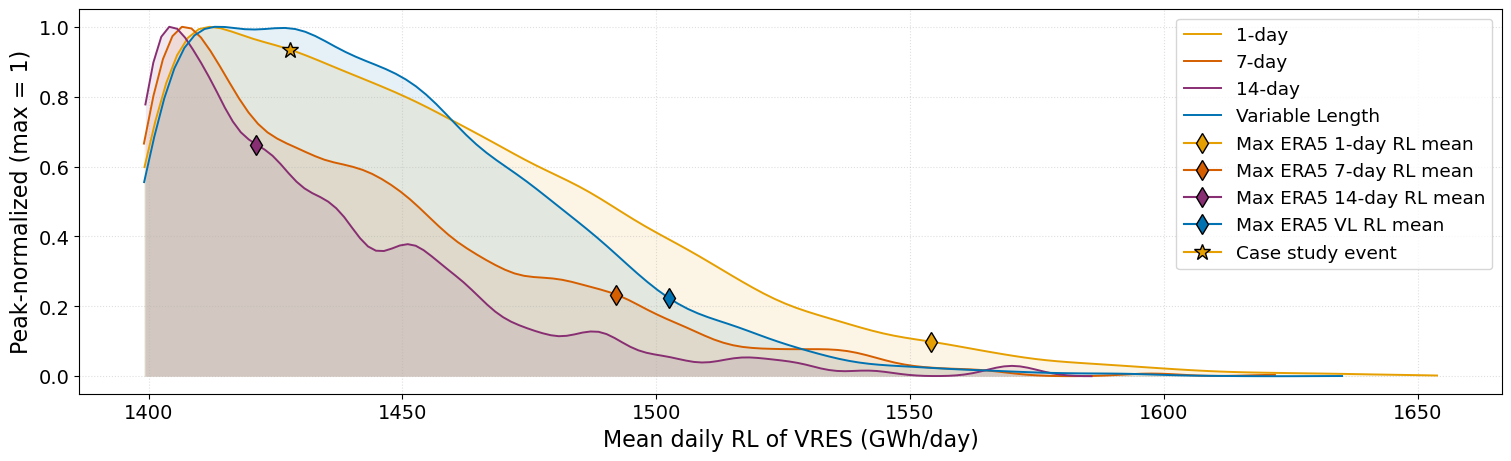

In [32]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# variables and appearance
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (15,4.5)  # figure size

color_1 = '#E69F00'
color_7 = '#D55E00'
color_14 = '#882E72'
color_vl = '#0072B2'

lw = 1.4  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)  

# for ax, (col, pretty) in zip(axes, columns):
a = LEE_dat['RL_mean'].values  # all data array
b = LEE_7['RL_mean'].values  # all data array
c = LEE_14['RL_mean'].values  # all data array
d = LEE_vl['RL_mean'].values  # all data array

# common bin edges spanning min..max across all 4 sets so curves align
edges = np.linspace(min(a.min(), b.min(), c.min(), d.min()), max(a.max(), b.max(), c.max(), d.max()), bins+1)  # bin edges
centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

edges_a = np.linspace(a.min(), a.max(), bins+1)
edges_b = np.linspace(b.min(), b.max(), bins+1)
edges_c = np.linspace(c.min(), c.max()+15, bins+1)
edges_d = np.linspace(d.min(), d.max(), bins+1)

centers_a = (edges_a[:-1] + edges_a[1:]) / 2.0  # bin centers
centers_b = (edges_b[:-1] + edges_b[1:]) / 2.0  # bin centers
centers_c = (edges_c[:-1] + edges_c[1:]) / 2.0  # bin centers
centers_d = (edges_d[:-1] + edges_d[1:]) / 2.0  # bin centers

# histogram counts (density=False -> raw counts) computed on the same edges
ca, _ = np.histogram(a, bins=edges_a, density=False)  # counts for all
cb, _ = np.histogram(b, bins=edges_b, density=False)  # counts for 7
cc, _ = np.histogram(c, bins=edges_c, density=False)  # counts for 14
cd, _ = np.histogram(d, bins=edges_d, density=False)  # counts for VL

# smooth counts by convolving with the gaussian kernel
sa = np.convolve(ca, kernel, mode='same')  # smoothed all
sb = np.convolve(cb, kernel, mode='same')  # smoothed 7
sc = np.convolve(cc, kernel, mode='same')  # smoothed 14
sd = np.convolve(cd, kernel, mode='same')  # smoothed VL

# normalize so the largest peak among the three equals 1 (same as your original)
peak_a = max(sa.max(), 1e-12)  # avoid division by zero
sa /= peak_a  # normalized all

peak_b = max(sb.max(), 1e-12)  # avoid division by zero
sb /= peak_b  # normalized 7

peak_c = max(sc.max(), 1e-12)  # avoid division by zero
sc /= peak_c  # normalized 14

peak_d = max(sd.max(), 1e-12)  # avoid division by zero
sd /= peak_d  # normalized VL

# plotting curves + fills
ax.plot(centers_a, sa, lw=lw, color=color_1, label='1-day')  # all curve
ax.plot(centers_b, sb, lw=lw, color=color_7, label='7-day')  # 7 curve
ax.plot(centers_c, sc, lw=lw, color=color_14, label='14-day')  # 14 curve
ax.plot(centers_d, sd, lw=lw, color=color_vl, label='Variable Length')  # VL curve

ax.fill_between(centers_a, sa, 0, color=color_1, alpha=fill_alpha, linewidth=0)  # fill all
ax.fill_between(centers_b, sb, 0, color=color_7, alpha=fill_alpha, linewidth=0)  # fill 7
ax.fill_between(centers_c, sc, 0, color=color_14, alpha=fill_alpha, linewidth=0)  # fill 14
ax.fill_between(centers_d, sd, 0, color=color_vl, alpha=fill_alpha, linewidth=0)  # fill VL

# --- Replace vertical lines with curve markers --------------------------------
# Get marker positions (x) for each curve
x1 = max(LEE_dat_ERA5['RL_mean'])
x7 = max(LEE_7_ERA5['RL_mean'])
x14 = max(LEE_14_ERA5['RL_mean'])
xvl = max(LEE_vl_ERA5['RL_mean'])
x_case = LEE_dat_ERA5[173:174]['RL_mean'].values[0]

# Helper to find y-value at a given x for a curve (linear interpolation)
def interp_y(x_points, y_points, x_target):
    return np.interp(x_target, x_points, y_points)

# Corresponding y values
y1 = interp_y(centers_a, sa, x1)
y7 = interp_y(centers_b, sb, x7)
y14 = interp_y(centers_c, sc, x14)
yvl = interp_y(centers_d, sd, xvl)
y_case = interp_y(centers_a, sa, x_case)  # or whichever curve fits your case study

# Plot markers instead of vertical lines
ax.plot(x1, y1, marker='d', color=color_1, markersize=10,
        markeredgecolor='k', label='Max ERA5 1-day RL mean')
ax.plot(x7, y7, marker='d', color=color_7, markersize=10,
        markeredgecolor='k', label='Max ERA5 7-day RL mean')
ax.plot(x14, y14, marker='d', color=color_14, markersize=10,
        markeredgecolor='k', label='Max ERA5 14-day RL mean')
ax.plot(xvl, yvl, marker='d', color=color_vl, markersize=10,
        markeredgecolor='k', label='Max ERA5 VL RL mean')
ax.plot(x_case, y_case, marker='*', color=color_1, markersize=12,
        markeredgecolor='k', label='Case study event')
# ------------------------------------------------------------------------------


# Add a vertical marker line at the most common RL_mean value
# ax.axvline(max(LEE_dat_ERA5['RL_mean']), color=color_1, linestyle='--', linewidth=2, label='Max ERA5 1-day RL mean')
# ax.axvline(max(LEE_7_ERA5['RL_mean']), color=color_7, linestyle='--', linewidth=2, label='Max ERA5 7-day RL mean')
# ax.axvline(max(LEE_14_ERA5['RL_mean']), color=color_14, linestyle='--', linewidth=2, label='Max ERA5 14-day RL mean')
# # ax.axvline(max(LEE_14['RL_mean']), color='blue', linestyle='--', linewidth=2, label='Specific event')
# # ax.axvline(max(LEE_7['RL_mean']), color='green', linestyle='--', linewidth=2, label='Specific event')


# ax.axvline(LEE_dat_ERA5[173:174]['RL_mean'].values[0], color='blue', linestyle='--', linewidth=2, label='Case study event')

# labels and styling
# ax.set_title('Smoothed distribution — Mean RL')  # subplot title
ax.set_xlabel('Mean daily RL of VRES (GWh/day)')  # x label
ax.set_ylabel('Peak-normalized (max = 1)')
ax.grid(True, linestyle=':', alpha=0.4)  # grid
ax.legend(fontsize='small')  # legend

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/LEE_RL_mean_distribution_with_VL.png', bbox_inches='tight', dpi=300)

plt.show()  # display


In [33]:
max(LEE_14['RL_mean'])

1571.5475769964792

### Check doy distribution

In [34]:
# # Function to create a list of dates from start_date to end_date from the LEE data
# def create_date_list(LEE_data):
#     """
#     Generates a list of date strings from the start_date to end_date
#     for each event in the LEE_data DataFrame.

#     Parameters:
#         LEE_data (pd.DataFrame): A DataFrame containing 'date_start' and 'date_end' columns.

#     Returns:
#         list: A list of date strings in 'YYYY-MM-DD' format.
#     """
#     date_list = []
#     for start, end in zip(LEE_data['date_start'], LEE_data['date_end']):
#         dates = pd.date_range(start=start, end=end, freq='D')
#         date_list.extend(d.strftime('%Y-%m-%d') for d in dates)
#     return date_list


In [35]:
# Precompute cumulative days at month start in a non-leap year
_NONLEAP_CUMDAYS = {1:   0, 2:  31, 3:  59, 4:  90, 5: 120, 6: 151, 7: 181, 8: 212, 9: 243, 10: 273, 11: 304, 12: 334}

def _md_to_doy(month: int, day: int) -> int:
    """
    Convert month/day in a non-leap year to day-of-year (1-365).
    """
    return _NONLEAP_CUMDAYS[month] + day

def create_doy_list(LEE_data: pd.DataFrame) -> list[int]:
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute their non-leap DOYs (1-365), and then return all DOYs in that interval
    (inclusive), wrapping across year-end if start > end.

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[int]: flat list of DOYs (1-365) covering each event.
    """
    doy_list: list[int] = []

    for start_str, end_str in zip(LEE_data['date_start'], LEE_data['date_end']):
        # parse out month/day
        ms, ds = datetime.strptime(start_str, "%Y-%m-%d").month, datetime.strptime(start_str, "%Y-%m-%d").day
        me, de = datetime.strptime(end_str,   "%Y-%m-%d").month, datetime.strptime(end_str,   "%Y-%m-%d").day

        start_doy = _md_to_doy(ms, ds)
        end_doy   = _md_to_doy(me, de)

        if start_doy <= end_doy:
            interval = range(start_doy, end_doy + 1)
        else:
            # wrap across year boundary
            interval = list(range(start_doy, 366)) + list(range(1, end_doy + 1))

        doy_list.extend(interval)

    return doy_list


In [36]:
LEE_dat_dl = create_doy_list(LEE_dat)
LEE_vl_dl = create_doy_list(LEE_vl)
LEE_7_dl = create_doy_list(LEE_7)
LEE_14_dl = create_doy_list(LEE_14)

### Check the LEE days for each month

In [37]:
# Precomputed non-leap month start DOYs
_MONTH_STARTS = {1:   1, 2:  32, 3:  60, 4:  91, 5: 121, 6: 152, 7: 182, 8: 213, 9: 244, 10: 274, 11: 305, 12: 335}

def plot_oct_apr_centered(doy, title, ax=None, left_axis=True, color= '#4c72b0'):
    """
    Plots a daily-DOY histogram for Oct1–Apr30, with winter (Nov–Apr)
    centered in the middle of the x-axis.

    Args:
        doy (iterable of int): List/array/Series of day-of-year values (1–365).
        ax (matplotlib.axes.Axes): Axes to plot into. If None, uses current axes.
        left_axis (bool): If True, show y-axis label/ticks; otherwise hide them.
    """
    if ax is None:
        ax = plt.gca()

    # 1) Shift winter by half-year so Nov–Apr appear centrally.
    # Use ((d-1)+182) % 365 + 1 to keep values in 1..365
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]

    # 2) Count occurrences for each shifted day and ensure full day-range is present
    counts = pd.Series(shifted).value_counts().sort_index()

    # 3) Compute tick positions for Oct→Apr month starts (shifted consistently)
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks = []
    labels = []
    month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
    for m in months:
        raw_start = _MONTH_STARTS[m]
        pos = ((raw_start - 1) + 182) % 365 + 1
        ticks.append(pos)
        labels.append(month_name[m])

    min_tick, max_tick = min(ticks), max(ticks)

    # 4) Reindex counts to include any missing days (fill with zeros) across the plotting window
    full_index = np.arange(min_tick, max_tick + 1, dtype=int)
    counts_full = counts.reindex(full_index, fill_value=0)

    # 5) Plot on provided axes
    ax.bar(full_index, counts_full.values, width=1.0, color=color, alpha=0.8)
    ax.set_xlim(min_tick - 0.5, max_tick + 0.5)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=18, loc='left')

    if left_axis:
        ax.set_ylabel("Count per Day", fontsize=16)
    else:
        # hide left tick labels to keep plot clean (works with sharey=True)
        ax.tick_params(labelleft=False)

    ax.grid(axis='y', linestyle='--', alpha=0.5)

In [38]:
doy = LEE_vl_dl
doy_series = pd.Series(doy)
most_common_doy = doy_series.value_counts().idxmax()
frequency = doy_series.value_counts().max()

print(f"Most common DOY: {most_common_doy}, Frequency: {frequency}")

Most common DOY: 21, Frequency: 203


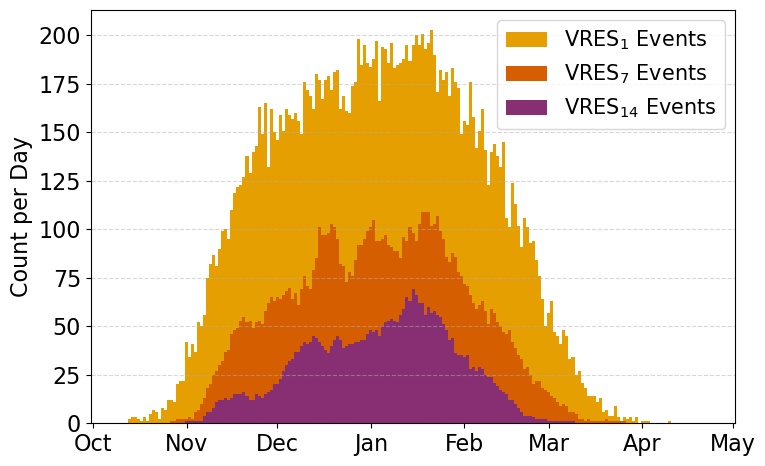

In [39]:
# Precomputed non-leap month start DOYs
_MONTH_STARTS = {1:   1, 2:  32, 3:  60, 4:  91, 5: 121, 6: 152, 7: 182, 8: 213, 9: 244, 10: 274, 11: 305, 12: 335}

# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16+2,
    'axes.titlesize': 18+2,
    'axes.labelsize': 16+2,
    'xtick.labelsize': 14+2,
    'ytick.labelsize': 14+2,
    'legend.fontsize': 14+1,
    'figure.titlesize': 18+2,
})

# months shown Oct -> May (so Oct..Apr are centered)
months = [10, 11, 12, 1, 2, 3, 4, 5]
month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}

# compute ticks (shifted as in your function) and global plotting window
ticks = []
labels = []
for m in months:
    raw_start = _MONTH_STARTS[m]
    pos = ((raw_start - 1) + 182) % 365 + 1
    ticks.append(pos)
    labels.append(month_name[m])

min_tick, max_tick = min(ticks), max(ticks)
full_index = np.arange(min_tick, max_tick + 1, dtype=int)

# Styling / data
colors = ['#E69F00', '#D55E00', '#882E72']
titles = [r'$\mathrm{VRES}_{1}$ Events', r'$\mathrm{VRES}_{7}$ Events', r'$\mathrm{VRES}_{14}$ Events']
doy_lists = [LEE_vl_dl, LEE_7_dl, LEE_14_dl]  # your DOY lists (1..365)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Prepare counts for each series (reindexed to common x window)
counts_all = []
for doy in doy_lists:
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]
    counts = pd.Series(shifted).value_counts().sort_index()
    counts_full = counts.reindex(full_index, fill_value=0)
    counts_all.append(counts_full.values)

# Overplot bars with slight horizontal offsets so bars are visible side-by-side
n_series = len(counts_all)
total_bar_fraction = 0.9                   # fraction of integer-day used by group of bars
bar_width = total_bar_fraction / n_series  # width for each individual series
offsets = (np.arange(n_series) - (n_series - 1) / 2) * bar_width

# exact overlap alternative (width=1.0, semi-transparent)
for counts_vals, color, label in zip(counts_all, colors, titles):
    ax.bar(full_index, counts_vals, width=1.0,color=color, label=label, align='center')

# axes formatting
ax.set_xlim(min_tick - 0.5 - bar_width, max_tick + 0.5 + bar_width)
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_ylabel("Count per Day", fontsize=16)
# ax.set_title("Daily DOY distributions (Oct 1 – Apr 30 window, winter-centered)", fontsize=18, loc='left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
# Save plot
# plt.savefig('/home/onennecke/Code/Figures/VRES_DOW_distribution.png', bbox_inches='tight', dpi=300)

plt.show()


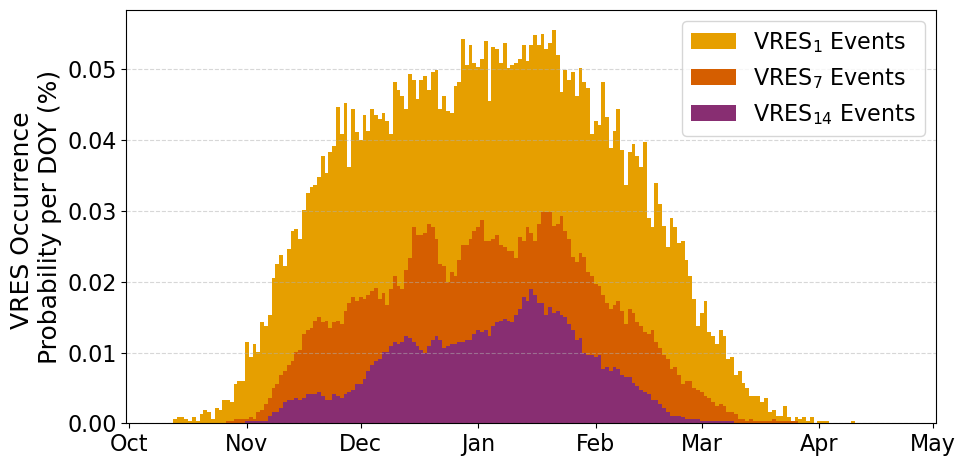

In [40]:
# Precomputed non-leap month start DOYs
_MONTH_STARTS = {1:   1, 2:  32, 3:  60, 4:  91, 5: 121, 6: 152, 7: 182, 8: 213, 9: 244, 10: 274, 11: 305, 12: 335}

# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16+2,
    'axes.titlesize': 18+2,
    'axes.labelsize': 16+2,
    'xtick.labelsize': 14+2,
    'ytick.labelsize': 14+2,
    'legend.fontsize': 14+2,
    'figure.titlesize': 18+2,
})

# months shown Oct -> May (so Oct..Apr are centered)
months = [10, 11, 12, 1, 2, 3, 4, 5]
month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}

# compute ticks (shifted as in your function) and global plotting window
ticks = []
labels = []
for m in months:
    raw_start = _MONTH_STARTS[m]
    pos = ((raw_start - 1) + 182) % 365 + 1
    ticks.append(pos)
    labels.append(month_name[m])

min_tick, max_tick = min(ticks), max(ticks)
full_index = np.arange(min_tick, max_tick + 1, dtype=int)

# Styling / data
colors = ['#E69F00', '#D55E00', '#882E72']
titles = [r'$\mathrm{VRES}_{1}$ Events', r'$\mathrm{VRES}_{7}$ Events', r'$\mathrm{VRES}_{14}$ Events']
doy_lists = [LEE_vl_dl, LEE_7_dl, LEE_14_dl]  # your DOY lists (1..365)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Prepare counts for each series (reindexed to common x window)
counts_all = []
for doy in doy_lists:
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]
    counts = pd.Series(shifted).value_counts().sort_index()
    counts_full = counts.reindex(full_index, fill_value=0)
    counts_full = counts_full / 365000 * 100  # convert to percentage probability
    counts_all.append(counts_full.values)

# Overplot bars with slight horizontal offsets so bars are visible side-by-side
n_series = len(counts_all)
total_bar_fraction = 0.9                   # fraction of integer-day used by group of bars
bar_width = total_bar_fraction / n_series  # width for each individual series
offsets = (np.arange(n_series) - (n_series - 1) / 2) * bar_width

# exact overlap alternative (width=1.0, semi-transparent)
for counts_vals, color, label in zip(counts_all, colors, titles):
    ax.bar(full_index, counts_vals, width=1.0,color=color, label=label, align='center')

# axes formatting
ax.set_xlim(min_tick - 0.5 - bar_width, max_tick + 0.5 + bar_width)
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_ylabel("VRES Occurrence \nProbability per DOY (%)")
# ax.set_title("Daily DOY distributions (Oct 1 – Apr 30 window, winter-centered)", fontsize=18, loc='left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
# Save plot
# plt.savefig('/home/onennecke/Code/Figures/VRES_DOW_distribution.png', bbox_inches='tight', dpi=300)

plt.show()


In [41]:
np.unique(doy)
shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]
len(np.unique(shifted))

129

In [42]:
def oct_apr_centered(doy):
    # 1) Shift winter by half-year so Nov–Apr appear centrally.
    # Use ((d-1)+182) % 365 + 1 to keep values in 1..365
    shifted = [((int(d) - 1) + 182) % 365 + 1 for d in doy]

    # 2) Count occurrences for each shifted day and ensure full day-range is present
    counts = pd.Series(shifted).value_counts().sort_index()

    # 3) Compute tick positions for Oct→Apr month starts (shifted consistently)
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks = []
    labels = []
    month_name = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
    for m in months:
        raw_start = _MONTH_STARTS[m]
        pos = ((raw_start - 1) + 182) % 365 + 1
        ticks.append(pos)
        labels.append(month_name[m])

    min_tick, max_tick = min(ticks), max(ticks)

    # 4) Reindex counts to include any missing days (fill with zeros) across the plotting window
    full_index = np.arange(min_tick, max_tick + 1, dtype=int)
    counts_full = counts.reindex(full_index, fill_value=0)

    return counts_full

In [43]:
LEE_vl_count = oct_apr_centered(LEE_vl_dl)
LEE_7_count = oct_apr_centered(LEE_7_dl)
LEE_14_count = oct_apr_centered(LEE_14_dl)


In [44]:
print([((int(274) - 1) + 182) % 365 + 1])
print([((int(121) - 1) + 182) % 365 + 1])
print([((int(203) - 1) + 182) % 365 + 1])
print([((int(20) - 1) + 182) % 365 + 1])

[91]
[303]
[20]
[202]


In [45]:
np.sort(LEE_vl_count)
lst = LEE_vl_count.nlargest(5).index.tolist()
for i in lst:
    print(i, ': ',[((int(i) - 1) + 182) % 365 + 1])

203 :  [20]
200 :  [17]
198 :  [15]
179 :  [361]
185 :  [2]


In [46]:
LEE_vl_count[40:60]
max(LEE_vl_count)
LEE_vl_count.idxmax()
LEE_vl_count[203]
LEE_vl_count[100:115]
# LEE_vl_count


191    183
192    185
193    186
194    188
195    195
196    187
197    195
198    200
199    195
200    201
201    193
202    196
203    203
204    190
205    171
Name: count, dtype: int64

In [47]:
LEE_vl_count.idxmax()
print([((int(LEE_vl_count.idxmax()) - 1) + 182) % 365 + 1])
print([((int(LEE_7_count.idxmax()) - 1) + 182) % 365 + 1])
print([((int(LEE_14_count.idxmax()) - 1) + 182) % 365 + 1])

[20]
[17]
[14]


In [48]:
LEE_14_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_14_dl]
LEE_7_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_7_dl]
LEE_dat_dl_shifted = [(((int(i) - 1) + 182) % 365 + 1) for i in LEE_dat_dl]


In [49]:
print(np.mean(LEE_14_dl_shifted))
print(np.median(LEE_14_dl_shifted))

185.97470817120623
188.5


In [50]:
'''from scipy import stats
import statsmodels.api as sm

# suppose `counts` is the array of daily counts for the 1-day events
# e.g. counts = np.array([...])
counts = np.array(tst)
# 1) Q-Q plot
sm.qqplot(counts, line='s')
plt.title('Q-Q plot against normal')
plt.show()

# 2) Normality tests
w, p_shapiro = stats.shapiro(counts)           # Shapiro-Wilk
k2, p_dagostino = stats.normaltest(counts)    # D'Agostino
ad_result = stats.anderson(counts, dist='norm')  # Anderson-Darling

print('Shapiro p=', p_shapiro)
print('D\'Agostino p=', p_dagostino)
print('Anderson statistic=', ad_result.statistic, 'critical=', ad_result.critical_values)'''


"from scipy import stats\nimport statsmodels.api as sm\n\n# suppose `counts` is the array of daily counts for the 1-day events\n# e.g. counts = np.array([...])\ncounts = np.array(tst)\n# 1) Q-Q plot\nsm.qqplot(counts, line='s')\nplt.title('Q-Q plot against normal')\nplt.show()\n\n# 2) Normality tests\nw, p_shapiro = stats.shapiro(counts)           # Shapiro-Wilk\nk2, p_dagostino = stats.normaltest(counts)    # D'Agostino\nad_result = stats.anderson(counts, dist='norm')  # Anderson-Darling\n\nprint('Shapiro p=', p_shapiro)\nprint('D'Agostino p=', p_dagostino)\nprint('Anderson statistic=', ad_result.statistic, 'critical=', ad_result.critical_values)"

In [51]:
'''data = np.array(LEE_14_dl_shifted)

# sample skewness (bias-corrected)
skew_corrected = stats.skew(data, bias=False)

# raw (uncorrected) moment skewness
skew_raw = stats.skew(data, bias=True)

print("skew (bias-corrected) =", skew_corrected)
print("skew (raw) =", skew_raw)'''

'data = np.array(LEE_14_dl_shifted)\n\n# sample skewness (bias-corrected)\nskew_corrected = stats.skew(data, bias=False)\n\n# raw (uncorrected) moment skewness\nskew_raw = stats.skew(data, bias=True)\n\nprint("skew (bias-corrected) =", skew_corrected)\nprint("skew (raw) =", skew_raw)'

### Test

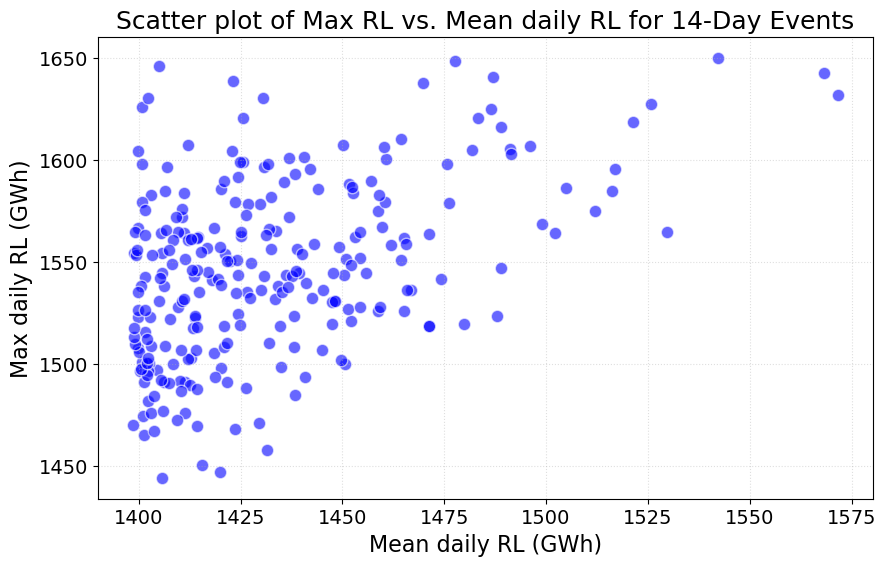

In [52]:
LEE_14
# Plot scatter of RLcumulative vs. RL_mean with different colors for ESM
# Set plot style
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 18,
})
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
scatter = ax.scatter(LEE_14['RL_mean'], LEE_14['RL_max'], c='blue', alpha=0.6, edgecolors='w', s=80)
# Labels and title
ax.set_ylabel('Max daily RL (GWh)')
ax.set_xlabel('Mean daily RL (GWh)')
ax.set_title('Scatter plot of Max RL vs. Mean daily RL for 14-Day Events')
ax.grid(True, linestyle=':', alpha=0.4)
# Show plot
plt.show()

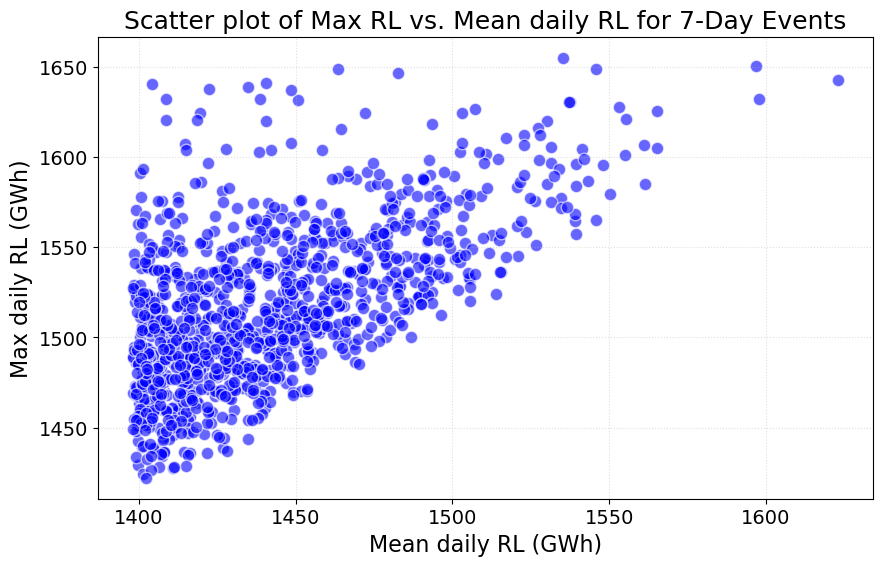

In [53]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 18,
})
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
scatter = ax.scatter(LEE_7['RL_mean'], LEE_7['RL_max'], c='blue', alpha=0.6, edgecolors='w', s=80)
# Labels and title
ax.set_ylabel('Max daily RL (GWh)')
ax.set_xlabel('Mean daily RL (GWh)')
ax.set_title('Scatter plot of Max RL vs. Mean daily RL for 7-Day Events')
ax.grid(True, linestyle=':', alpha=0.4)
# Show plot
plt.show()

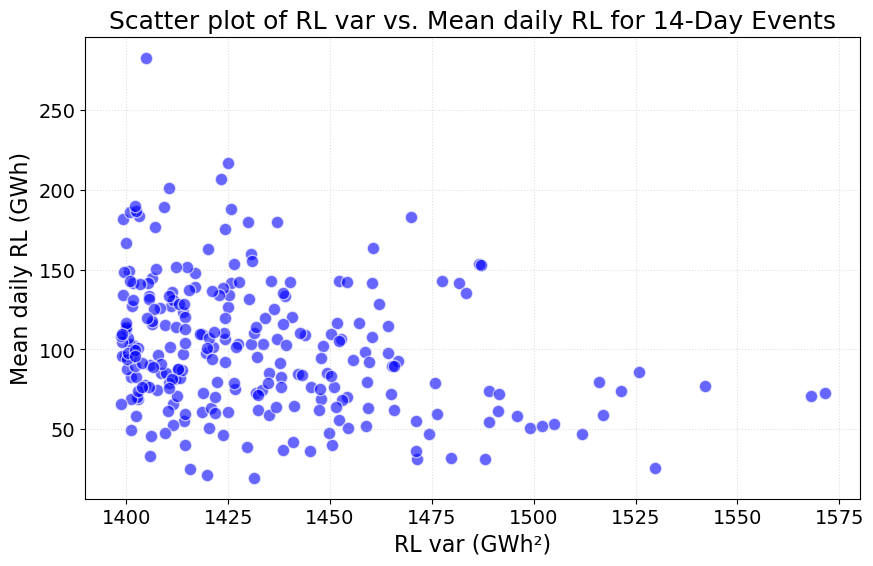

In [54]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 18,
})
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
scatter = ax.scatter(LEE_14['RL_mean'], LEE_14['RL_var'], c='blue', alpha=0.6, edgecolors='w', s=80)
# Labels and title
ax.set_xlabel('RL var (GWh²)')
ax.set_ylabel('Mean daily RL (GWh)')
ax.set_title('Scatter plot of RL var vs. Mean daily RL for 14-Day Events')
ax.grid(True, linestyle=':', alpha=0.4)
# Show plot
plt.show()

In [55]:
LEE_7['time_to_max'] = LEE_7['index_peak'] - LEE_7['index_start']
LEE_14['time_to_max'] = LEE_14['index_peak'] - LEE_14['index_start']
LEE_vl['time_to_max'] = LEE_vl['index_peak'] - LEE_vl['index_start']


In [56]:
print('Mean time to max (7-day):', np.mean(LEE_7['time_to_max']))
print('Median time to max (7-day):', np.median(LEE_7['time_to_max']))
print('Mode time to max (7-day):', stats.mode(LEE_7['time_to_max']))

print('Mean time to max (14-day):', np.mean(LEE_14['time_to_max']))
print('Median time to max (14-day):', np.median(LEE_14['time_to_max']))
print('Mode time to max (14-day):', stats.mode(LEE_14['time_to_max']))

Mean time to max (7-day): 3.4107773851590104
Median time to max (7-day): 4.0
Mode time to max (7-day): ModeResult(mode=np.int64(5), count=np.int64(255))
Mean time to max (14-day): 7.287937743190661
Median time to max (14-day): 7.0
Mode time to max (14-day): ModeResult(mode=np.int64(6), count=np.int64(28))


In [57]:
LEE_vl_long = LEE_vl[LEE_vl['duration'] >= 14]

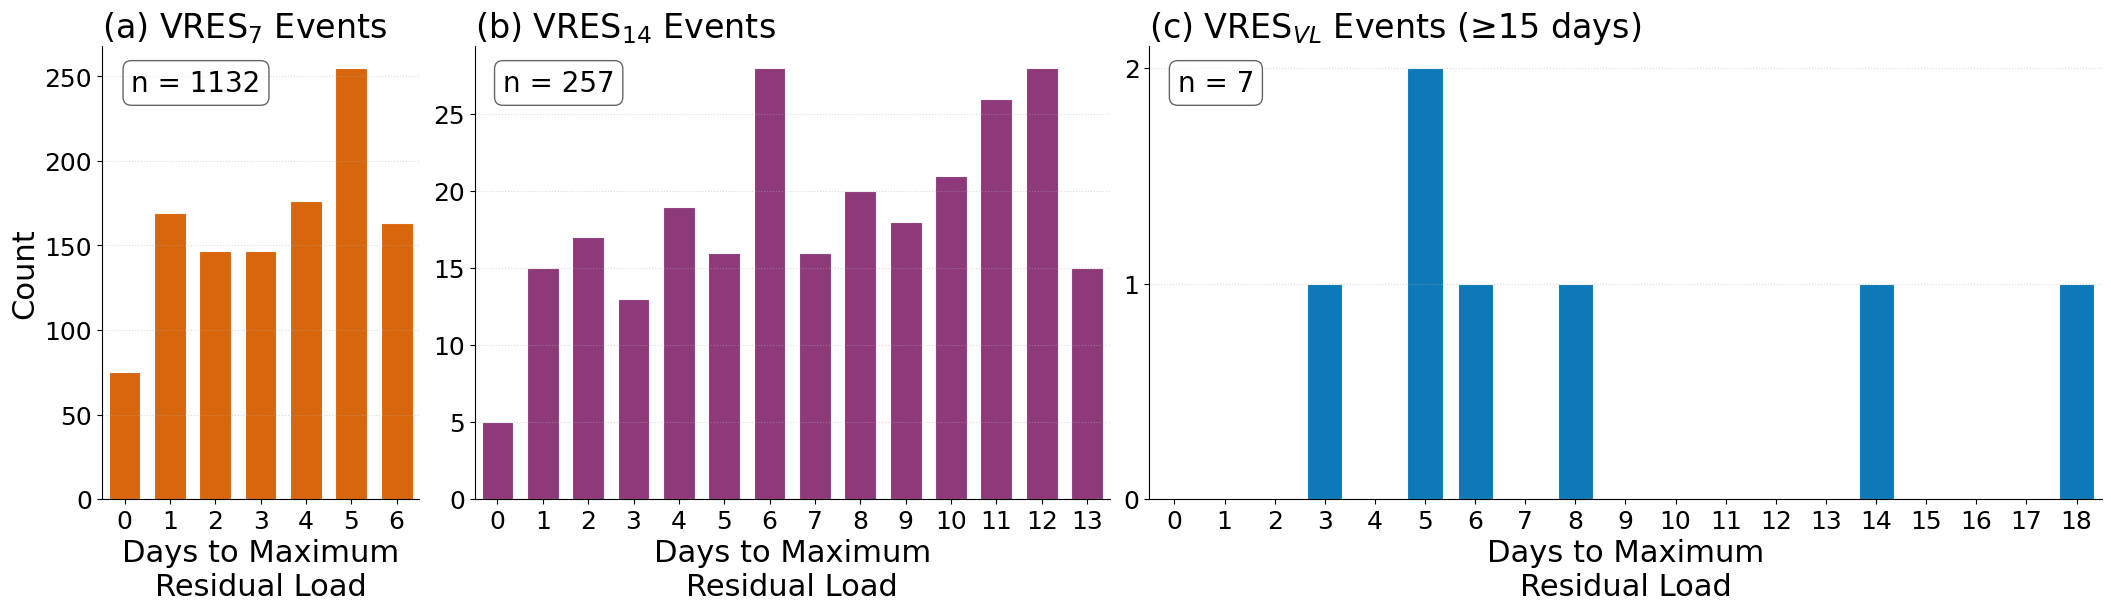

In [59]:
# --- Style settings (cleaner) ---
mpl.rcParams.update({
    'font.size': 18+2,
    'axes.titlesize': 22+2,
    'axes.labelsize': 20+2,
    'xtick.labelsize': 16+2,
    'ytick.labelsize': 16+2,
    'legend.fontsize': 16+2,
    'figure.titlesize': 22+2,
})

# --- Colors ---
color_7  = '#D55E00'
color_14 = '#882E72'
color_vl = '#0072B2'

# --- Data arrays ---
data7  = pd.Series(LEE_7['time_to_max']).dropna().to_numpy()
data14 = pd.Series(LEE_14['time_to_max']).dropna().to_numpy()
data_vl = pd.Series(LEE_vl_long['time_to_max']).dropna().to_numpy()

# --- Figure setup: narrower first subplot ---
fig, axes = plt.subplots(
    1, 3,
    figsize=(21, 6),
    gridspec_kw={'width_ratios': [0.3, 0.6, 0.9]},  # first narrower, others normal
    constrained_layout=True
)

bar_width = 0.7
datasets = [
    (data7,  color_7,  r'(a) $\mathrm{VRES}_{7}$ Events'),
    (data14, color_14, r'(b) $\mathrm{VRES}_{14}$ Events'),
    (data_vl, color_vl, r'(c) $\mathrm{VRES}_{VL}$ Events (≥15 days)')
]

# --- Unified plotting loop ---
for ax, (data, color, title) in zip(axes, datasets):
    min_val, max_val = 0, int(np.ceil(np.max(data)))
    bins = np.arange(min_val - 0.5, max_val + 0.5 + 1e-8, 1.0)
    counts, edges = np.histogram(data, bins=bins)
    centers = edges[:-1] + 0.5
    
    ax.bar(centers, counts, width=bar_width, align='center',
           edgecolor='white', linewidth=0.8, alpha=0.95, color=color)
    
    ax.set_xticks(np.arange(min_val, max_val + 1))
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_xlabel('Days to Maximum\nResidual Load')
    ax.set_title(title, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.45)
    if ax == axes[0]:
        ax.text(0.5, 0.95, f"n = {len(data)}",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
    elif ax == axes[1]:
        ax.text(0.22, 0.95, f"n = {len(data)}",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
    else:
        ax.text(0.11, 0.95, f"n = {len(data)}",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

axes[0].set_ylabel('Count')

# Optional: integer y-ticks for last panel
max_count = int(np.max(np.histogram(data_vl, bins=bins)[0]))
axes[2].set_yticks(np.arange(0, max_count + 1, 1))

# Save plot
plt.savefig('/home/onennecke/Code/Figures/VRES_time_to_max_distribution.png', bbox_inches='tight', dpi=300)
plt.show()


### Check how the LEE Days are distributed over the modells

In [61]:
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
LEE_all_comp

# Add a CMIP6 row (Exclude ERA5) for total duration across all ESMs
cmip6_duration = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['LEE_vl_dur_sum'].sum()
cmip6_nr_of_runs = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['Nr_of_runs'].sum()
cmip6_row = pd.DataFrame({'ESM': ['CMIP6'], 'LEE_vl_dur_sum': [cmip6_duration], 'Nr_of_runs': [cmip6_nr_of_runs]})
LEE_all_comp = pd.concat([LEE_all_comp, cmip6_row], ignore_index=True)
LEE_all_comp

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,time_to_max,Nr_of_runs,LEE_vl_dur_sum
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4.0,4.0,4.0,1.0,1423.036821,1423.036821,0.000000,1423.036821,1.0,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015.0,5.0,0.0,3,641
1,2015-01-08,2015-01-08,2015-01-08 00:00:00.000000000,7.0,7.0,7.0,1.0,1422.965439,1422.965439,0.000000,1422.965439,342.0,BCC-CSM2-MR,BCC-CSM2-MR_r1i1p1f1,2015.0,8.0,0.0,1,229
2,2015-01-23,2015-01-23,2015-01-23 00:00:00.000000000,22.0,22.0,22.0,1.0,1406.946003,1406.946003,0.000000,1406.946003,453.0,CESM2,CESM2_r10i1p1f1,2015.0,23.0,0.0,3,298
3,2015-01-03,2015-01-03,2015-01-03 00:00:00.000000000,2.0,2.0,2.0,1.0,1454.766468,1454.766468,0.000000,1454.766468,630.0,EC-Earth3,EC-Earth3_r101i1p1f1,2015.0,3.0,0.0,53,8328
4,2015-01-19,2015-01-24,2015-01-19 00:00:00.000000004,18.0,23.0,22.0,6.0,1497.249011,1465.148179,28.387418,8790.889073,5150.0,ERA5_week,ERA5_hist_week,2015.0,19.0,4.0,1,183
5,2015-01-06,2015-01-07,2015-01-06 00:00:00.000000000,5.0,6.0,5.0,2.0,1562.183529,1560.307028,1.876501,3120.614056,5392.0,GFDL-ESM4,GFDL-ESM4_r1i1p1f1,2015.0,6.0,0.0,1,165
6,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2.0,3.0,2.0,2.0,1482.439256,1461.158470,21.280786,2922.316940,5483.0,KACE-1-0-G,KACE-1-0-G_r1i1p1f1,2015.0,3.0,0.0,3,330
7,2015-01-02,2015-01-02,2015-01-02 00:00:00.000000000,1.0,1.0,1.0,1.0,1401.586013,1401.586013,0.000000,1401.586013,5638.0,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r10i1p1f1,2015.0,2.0,0.0,10,2431
8,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2.0,3.0,2.0,2.0,1479.659890,1478.350301,1.309589,2956.700602,6809.0,MRI-ESM2-0,MRI-ESM2-0_r1i1p1f1,2015.0,3.0,0.0,5,715
9,2015-01-01,2015-01-01,2015-01-01 00:00:00.000000000,0.0,0.0,0.0,1.0,1437.103803,1437.103803,0.000000,1437.103803,7167.0,TaiESM1,TaiESM1_r1i1p1f1,2015.0,1.0,0.0,1,141


In [62]:
# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
# LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values
# Add a CMIP6 row (Exclude ERA5) for total duration across all ESMs
cmip6_duration = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['LEE_vl_dur_sum'].sum()
cmip6_nr_of_runs = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['Nr_of_runs'].sum()
cmip6_row = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_vl_dur_sum': [cmip6_duration], 'Nr_of_runs': [cmip6_nr_of_runs]})
LEE_all_comp = pd.concat([LEE_all_comp, cmip6_row], ignore_index=True)

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_vl_dur_avg_ranking'] = LEE_all_comp['LEE_vl_dur_avg'].rank(ascending=False)
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg', 'LEE_vl_dur_avg_ranking']]


# LEE_dat_temp = LEE_dat.copy()
# LEE_dat_temp['LEE_dat_dur_sum'] = LEE_dat_temp.groupby('ESM')['duration'].transform('sum')
# LEE_dat_temp = LEE_dat_temp.drop_duplicates(subset=['ESM', 'LEE_dat_dur_sum'])
# LEE_dat_temp
# Join the two DataFrames on 'ESM'
# LEE_all_comp = LEE_all_comp.merge(LEE_dat_temp[['ESM', 'LEE_dat_dur_sum']], on='ESM', how='left')
# LEE_all_comp['LEE_dat_dur_avg'] = LEE_all_comp['LEE_dat_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
cmip6_duration_7 = LEE_7_temp[LEE_7_temp['ESM'] != 'ERA5_week']['LEE_7_dur_sum'].sum()
cmip6_nr_of_runs_7 = LEE_7_temp[LEE_7_temp['ESM'] != 'ERA5_week']['ESM_run'].nunique()
cmip6_row_7 = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_7_dur_sum': [cmip6_duration_7], 'Nr_of_runs': [cmip6_nr_of_runs_7]})
LEE_7_temp = pd.concat([LEE_7_temp, cmip6_row_7], ignore_index=True)
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_7_dur_avg_ranking'] = LEE_all_comp['LEE_7_dur_avg'].rank(ascending=False)

LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
cmip6_duration_14 = LEE_14_temp[LEE_14_temp['ESM'] != 'ERA5_week']['LEE_14_dur_sum'].sum()
cmip6_nr_of_runs_14 = LEE_14_temp[LEE_14_temp['ESM'] != 'ERA5_week']['ESM_run'].nunique()
cmip6_row_14 = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_14_dur_sum': [cmip6_duration_14], 'Nr_of_runs': [cmip6_nr_of_runs_14]})
LEE_14_temp = pd.concat([LEE_14_temp, cmip6_row_14], ignore_index=True)
LEE_14_temp
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_14_dur_avg_ranking'] = LEE_all_comp['LEE_14_dur_avg'].rank(ascending=False)

LEE_all_comp['ESM_label'] = LEE_all_comp['ESM'] + ' \n (n = ' + LEE_all_comp['Nr_of_runs'].astype(str) + ')'
# Fix the label for ERA5_week to display as "ERA5 \n (n = 1)"
LEE_all_comp.loc[LEE_all_comp['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5 \n (n = 1)'
LEE_all_comp


,ESM,Nr_of_runs,LEE_vl_dur_sum,LEE_vl_dur_avg,LEE_vl_dur_avg_ranking,LEE_7_dur_sum,LEE_7_dur_avg,LEE_7_dur_avg_ranking,LEE_14_dur_sum,LEE_14_dur_avg,LEE_14_dur_avg_ranking,ESM_label
0,ACCESS-CM2,3,641,213.666667,4.0,280,93.333333,4.0,112.0,37.333333,4.0,ACCESS-CM2 \n (n = 3)
1,BCC-CSM2-MR,1,229,229.000000,3.0,119,119.000000,2.0,84.0,84.000000,1.0,BCC-CSM2-MR \n (n = 1)
2,CESM2,3,298,99.333333,12.0,154,51.333333,10.0,28.0,9.333333,11.0,CESM2 \n (n = 3)
3,EC-Earth3,53,8328,157.132075,8.0,3297,62.207547,9.0,1204.0,22.716981,8.0,EC-Earth3 \n (n = 53)
4,ERA5_week,1,183,183.000000,5.0,70,70.000000,6.5,28.0,28.000000,7.0,ERA5 \n (n = 1)
5,GFDL-ESM4,1,165,165.000000,7.0,70,70.000000,6.5,NaN,NaN,NaN,GFDL-ESM4 \n (n = 1)
6,KACE-1-0-G,3,330,110.000000,11.0,147,49.000000,11.0,56.0,18.666667,9.0,KACE-1-0-G \n (n = 3)
7,MPI-ESM1-2-HR,10,2431,243.100000,2.0,1078,107.800000,3.0,602.0,60.200000,3.0,MPI-ESM1-2-HR \n (n = 10)
8,MRI-ESM2-0,5,715,143.000000,9.0,315,63.000000,8.0,154.0,30.800000,6.0,MRI-ESM2-0 \n (n = 5)
9,TaiESM1,1,141,141.000000,10.0,42,42.000000,12.0,14.0,14.000000,10.0,TaiESM1 \n (n = 1)


In [63]:
print(252.105263 / 99 * 100)
print(124.157895 / 49 * 100)
print(84.000000 / 9.3 * 100)

254.65178080808082
253.38345918367344
903.2258064516128


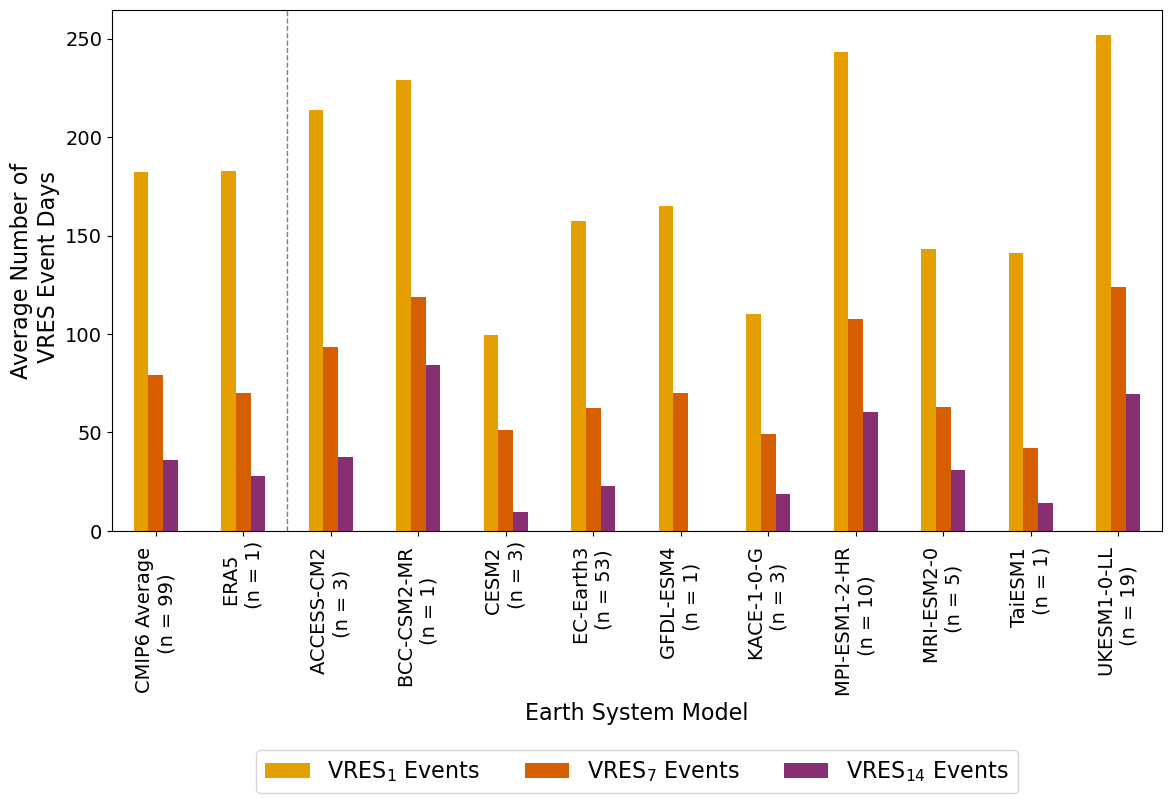

In [66]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# pick the 3 columns we want
df = LEE_all_comp.set_index('ESM_label')[['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']].copy()

# find ERA5 label (works if label contains extra text like "ERA5\n(n = 1)")
era_label = next((lab for lab in df.index if 'ERA5' in lab), None)
cmip_label = next((lab for lab in df.index if 'CMIP6' in lab), None)

# reorder so ERA5 is first, then the rest (no blank rows)
new_index = [cmip_label]+[era_label] + [lab for lab in df.index if lab != era_label and lab != cmip_label]
df_reordered = df.loc[new_index]

# plot grouped bars
ax = df_reordered.plot(kind='bar', color=['#E69F00', '#D55E00', '#882E72'], figsize=(12, 9))

# draw a dashed vertical line between ERA5 and the rest
era_pos = new_index.index(era_label)  # should be 0, but computed generally
# place line halfway between ERA5 group and the next group
x_line = era_pos + 0.5
ax.axvline(x=x_line, color="#7E7E7E", linestyle='--', linewidth=1, label='_nolegend_')

# cosmetics
legend = [r'$\mathrm{VRES}_{1}$ Events', r'$\mathrm{VRES}_{7}$ Events', r'$\mathrm{VRES}_{14}$ Events']
# ax.set_title('Average Sum of VRES Days per ESM')
ax.legend(legend, loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
ax.set_ylabel('Average Number of\n VRES Event Days')
ax.set_xlabel('Earth System Model')
ax.set_xticklabels(df_reordered.index, rotation=90)
plt.tight_layout()

plt.savefig('/home/onennecke/Code/Figures/LEE_durations_comparison.png', dpi=300, bbox_inches='tight')

plt.show()


# VL Events analysis

In [47]:
LEE_vl['duration'].max()

np.int64(23)

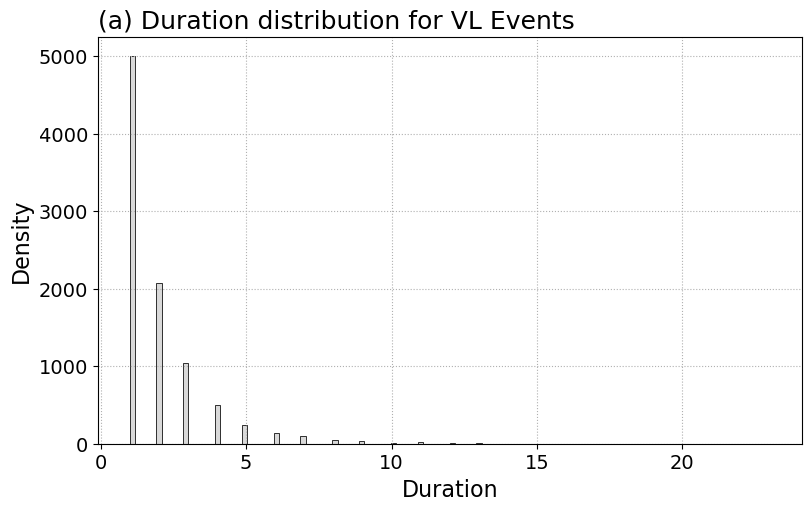

In [48]:
# --- changed code: single smoothed histogram for LEE_vl['duration'] ---

bins = 120
figsize = (8,5)
color_fill = '#d9d9d9'
edge_color = '#111111'
fill_alpha = 1
lw_edge = 0.6

# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# extract duration array
dur = np.asarray(LEE_vl['duration']).ravel()

# plotting
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# standard histogram (density=True -> area sums to 1)
ax.hist(dur, bins=bins, density=False, log=False,
        color=color_fill, alpha=fill_alpha,
        edgecolor=edge_color, linewidth=lw_edge)

ax.set_xlabel('Duration')
ax.set_ylabel('Density')
ax.set_title("(a) Duration distribution for VL Events", loc='left')
ax.grid(True, linestyle=':', alpha=1)

# plt.savefig('/home/onennecke/Code/Figures/VL_LEE_duration_histogram.png', bbox_inches='tight', dpi=300)
plt.show()


In [49]:
LEE_vl.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,time_to_max,Nr_of_runs
7481,2023-11-18,2023-12-10,2023-11-18 00:00:00.000000014,3241,3263,3255,23,1518.845215,1455.361885,33.685570,33473.323366,7482,UKESM1-0-LL,UKESM1-0-LL_r11i1p1f2,2023,322,14,19
6581,2017-01-02,2017-01-21,2017-01-02 00:00:00.000000018,731,750,749,20,1519.938828,1473.785364,31.958385,29475.707282,6582,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r8i1p1f1,2017,2,18,10
7395,2017-01-01,2017-01-19,2017-01-01 00:00:00.000000003,730,748,733,19,1650.189929,1535.789631,70.122670,29180.002998,7396,UKESM1-0-LL,UKESM1-0-LL_r11i1p1f2,2017,1,3,19
6168,2020-11-29,2020-12-15,2020-11-29 00:00:00.000000008,2157,2173,2165,17,1564.573329,1513.522835,43.637916,25729.888203,6169,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r4i1p1f1,2020,333,8,10
7903,2019-12-28,2020-01-11,2019-12-28 00:00:00.000000005,1821,1835,1826,15,1642.508641,1564.576632,69.816188,23468.649479,7904,UKESM1-0-LL,UKESM1-0-LL_r15i1p1f2,2019,362,5,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9366,2024-01-21,2024-01-21,2024-01-21 00:00:00.000000000,3305,3305,3305,1,1416.096851,1416.096851,0.000000,1416.096851,9367,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,21,0,19
9365,2024-01-07,2024-01-07,2024-01-07 00:00:00.000000000,3291,3291,3291,1,1449.493442,1449.493442,0.000000,1449.493442,9366,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,7,0,19
9364,2024-01-01,2024-01-01,2024-01-01 00:00:00.000000000,3285,3285,3285,1,1429.298227,1429.298227,0.000000,1429.298227,9365,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,1,0,19
9363,2023-12-30,2023-12-30,2023-12-30 00:00:00.000000000,3283,3283,3283,1,1421.535351,1421.535351,0.000000,1421.535351,9364,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,364,0,19


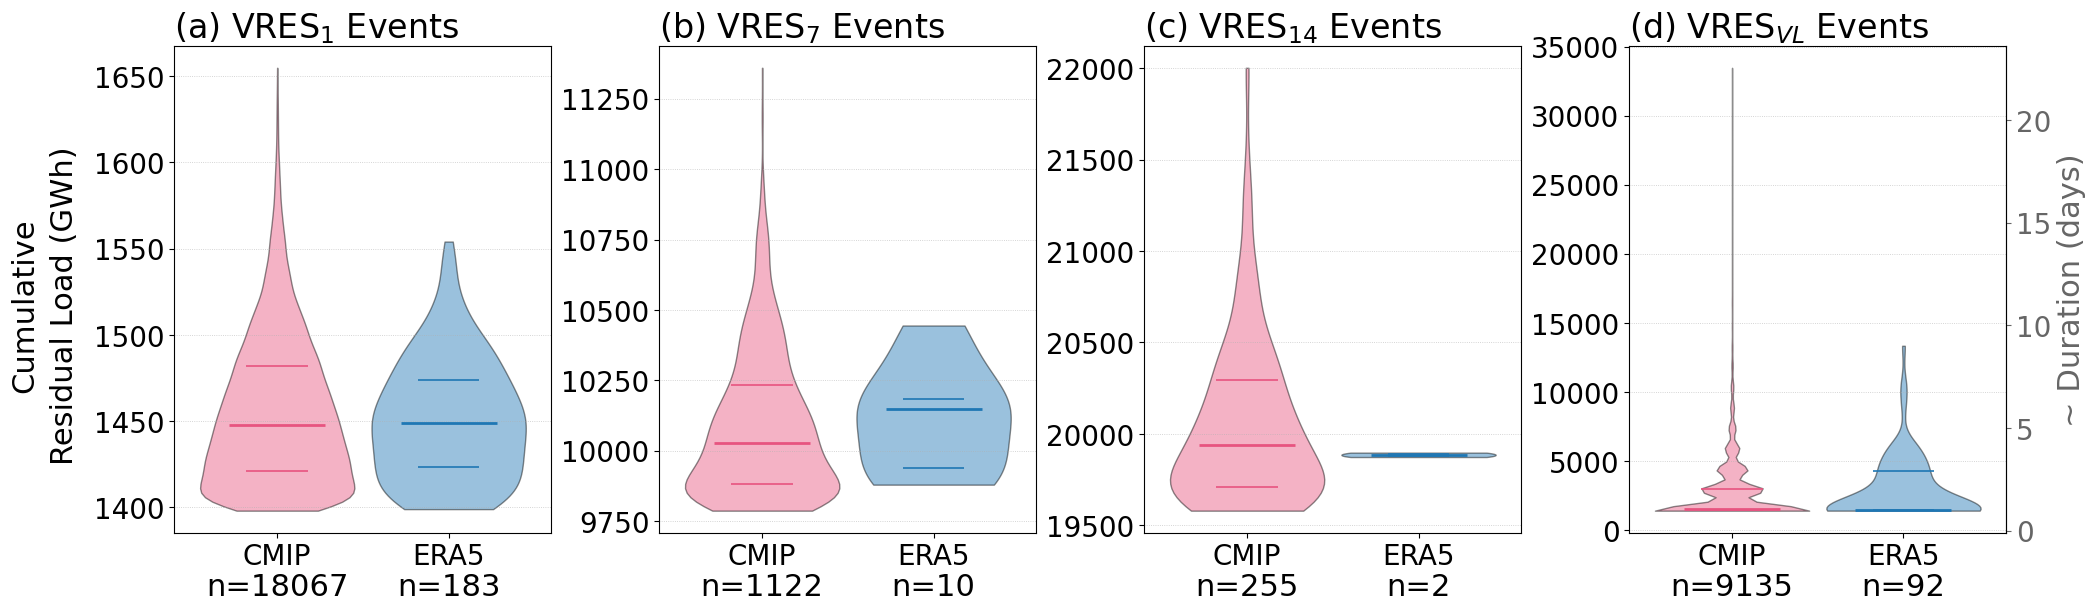

In [46]:

# keep text sizing consistent (you already had this; repeat so function is self-contained)
plt.rcParams.update({
    'font.size': 16+6,
    'axes.titlesize': 18+6,
    'axes.labelsize': 16+6,
    'xtick.labelsize': 14+6,
    'ytick.labelsize': 14+6,
    'legend.fontsize': 16+6,
    'figure.titlesize': 20+6,
})

def plot_violin_with_secondary(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    cmip_vl, era_vl,
    cmip_vl_dur, era_vl_dur,
    outpath=None,
    colors=None,
    figsize=(20, 6),
    title_suffix="",
    annotate_stats=True,
):
    """
    4-panel violin plot: 1d, 7d, 14d, VL (VL has secondary y-axis that maps RL -> duration).
    Secondary axis mapping is a linear fit from RL -> duration using combined CMIP+ERA5 VL data.

    PARAMETERS: same meaning as your earlier function. Arrays expected to be 1D numpy arrays or similar.
    """

    # default colors if None
    if colors is None:
        colors = ['#e75480', '#1f77b4']  # CMIP, ERA5

    datasets = [
        (cmip_1, era_1, r"(a) $\mathrm{VRES}_{1}$ Events"),
        (cmip_7, era_7, r"(b) $\mathrm{VRES}_{7}$ Events"),
        (cmip_14, era_14, r"(c) $\mathrm{VRES}_{14}$ Events"),
        (cmip_vl, era_vl, r"(d) $\mathrm{VRES}_{VL}$ Events"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    for ax, (cmip, era, title) in zip(axes, datasets):
        # violinplot: positions 1 and 2
        parts = ax.violinplot(dataset=[cmip, era], positions=[1, 2], vert=True,
                              widths=0.9, showextrema=False, showmedians=False)

        # style violin bodies
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # summary stats
        def safe_stats(arr):
            arr = np.asarray(arr)
            arr = arr[~np.isnan(arr)]
            return {
                'median': np.median(arr) if arr.size else np.nan,
                'q1': np.percentile(arr, 25) if arr.size else np.nan,
                'q3': np.percentile(arr, 75) if arr.size else np.nan,
                'min': np.min(arr) if arr.size else np.nan,
                'max': np.max(arr) if arr.size else np.nan,
                'n': arr.size,
            }

        s_cmip = safe_stats(cmip)
        s_era  = safe_stats(era)

        for i, pos in enumerate([1, 2]):
            stats = s_cmip if i == 0 else s_era
            color = colors[i]
            # median
            if not np.isnan(stats['median']):
                ax.hlines(stats['median'], pos - 0.28, pos + 0.28, color=color, linewidth=2.0)
            # quartiles
            if not np.isnan(stats['q1']) and not np.isnan(stats['q3']):
                ax.hlines(stats['q1'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
                ax.hlines(stats['q3'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
            # min/max ticks
            if not np.isnan(stats['min']):
                ax.vlines(pos - 0.08, stats['min'], stats['min'], color=color, linewidth=2.0)
            if not np.isnan(stats['max']):
                ax.vlines(pos + 0.08, stats['max'], stats['max'], color=color, linewidth=2.0)

            # sample size annotation (use axis transform so it sits relative to axis)
            ax.text(pos, -0.14, f"n={stats['n']}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', color='black')

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['CMIP', 'ERA5'])
        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)
        ax.set_xlim(0.4, 2.6)

    # Now add secondary axis to the VL panel (last axis)
    ax_vl = axes[-1]

    # Prepare data for fit: combine CMIP+ERA5 VL RL and corresponding durations
    X = np.concatenate([np.asarray(cmip_vl).ravel(), np.asarray(era_vl).ravel()])
    Y = np.concatenate([np.asarray(cmip_vl_dur).ravel(), np.asarray(era_vl_dur).ravel()])

    # remove nans and infinities
    mask = np.isfinite(X) & np.isfinite(Y)
    Xf = X[mask]
    Yf = Y[mask]

    # fallback identity mapping if not enough points or degenerate fit

    # linear fit RL -> duration
    slope, intercept = np.polyfit(Xf, Yf, 1)
    # predicted and R^2
    Ypred = slope * Xf + intercept
    ss_res = np.sum((Yf - Ypred)**2)
    ss_tot = np.sum((Yf - np.mean(Yf))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # guard against near-zero slope
    if abs(slope) < 1e-12:
        def forward(y): return y
        def inverse(d): return d
        fit_text = "Fit slope ~ 0; secondary axis = identity"
    else:
        def forward(y, a=slope, b=intercept): return a * y + b      # primary_y -> duration
        def inverse(d, a=slope, b=intercept): return (d - b) / a   # duration -> primary_y
        fit_text = f"duration ≈ {slope:.3e} * RL + {intercept:.3f}"

    # create secondary y-axis using conversion functions (primary->secondary, secondary->primary)
    secax = ax_vl.secondary_yaxis('right', functions=(forward, inverse))
    # Make the secondary y-axis visually lighter / auxiliary-looking
    secax.spines['right'].set_color("#666666")  # lighter spine color

    # lighter tick and label color
    secax.yaxis.label.set_color('#666666')
    secax.tick_params(axis='y', colors='#666666')

    # lighter dashed grid for the secondary axis (optional: only draw ticks/grid for secondary, not heavy)
    secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)

    # # if you want the secondary tick labels slightly smaller or rotated:
    # secax.tick_params(axis='y', which='major', labelsize=12)

    # ensure the secondary axis has lower zorder so it doesn't dominate
    secax.set_zorder(1)
    ax_vl.set_zorder(2)

    secax.set_ylabel('~ Duration (days)')

    # # annotate fit stats on VL panel
    # stats_txt = f"{fit_text}\nR² = {r2:.3f}" if not np.isnan(r2) else fit_text
    # # put box in top-right of VL subplot
    # ax_vl.text(0.98, 0.98, stats_txt, transform=ax_vl.transAxes,
    #             ha='right', va='top', fontsize=12, bbox=dict(boxstyle="round,pad=0.4", alpha=0.15))

    # # Optionally perform a KS test between the RL distribution and duration distribution
    # from scipy.stats import ks_2samp
    #     # compare combined RL vs combined duration (note: units differ; this is just a diagnostic)

    # ks_stat, ks_p = ks_2samp(np.concatenate([np.asarray(cmip_vl).ravel(), np.asarray(era_vl).ravel()]),
    #                         np.concatenate([np.asarray(cmip_vl_dur).ravel(), np.asarray(era_vl_dur).ravel()]))
    # ax_vl.text(0.02, 0.98, f"KS stat={ks_stat:.3f}, p={ks_p:.3f}", transform=ax_vl.transAxes,
    #             ha='left', va='top', fontsize=12, bbox=dict(boxstyle="round,pad=0.4", alpha=0.15))


    # Shared y-label on the left for clarity
    fig.text(-0.04, 0.5, 'Cumulative', va='center', rotation='vertical')
    fig.text(-0.02, 0.5, 'Residual Load (GWh)', va='center', rotation='vertical')

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes

# Example usage (your variables should be defined in the namespace):
fig, axes = plot_violin_with_secondary(
    cmip_1  = LEE_dat_CMIP['RL_cumulative'],
    era_1   = LEE_dat_ERA5['RL_cumulative'],
    cmip_7  = LEE_7_CMIP['RL_cumulative'],
    era_7   = LEE_7_ERA5['RL_cumulative'],
    cmip_14 = LEE_14_CMIP['RL_cumulative'],
    era_14  = LEE_14_ERA5['RL_cumulative'],
    cmip_vl = LEE_vl_CMIP['RL_cumulative'],
    era_vl  = LEE_vl_ERA5['RL_cumulative'],
    cmip_vl_dur = LEE_vl_CMIP['duration'],
    era_vl_dur  = LEE_vl_ERA5['duration'],
    outpath='/home/onennecke/Code/Figures/VRES_RL_cumulative_violin_comparison.png',
)


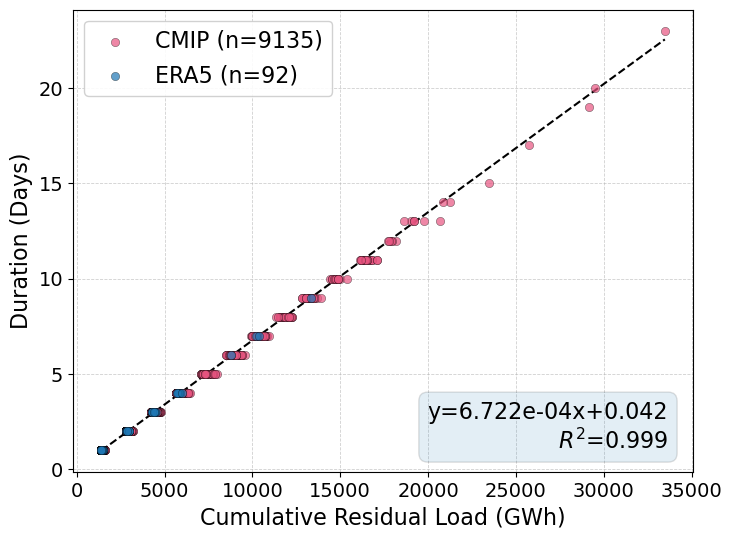

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Cumulative Residual Load (GWh)', ylabel='Duration (Days)'>)

In [49]:
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# If you have scipy you can compute a more formal r-value; otherwise we compute R^2 manually
try:
    from scipy.stats import linregress
    _have_scipy = True
except Exception:
    _have_scipy = False

def scatter_rl_vs_duration(
    cmip_rl, cmip_dur,
    era_rl, era_dur,
    figsize=(8,6),
    colors=['#e75480', '#1f77b4'],
    title="VL events: cumulative RL vs duration",
    outpath=None
):
    # flatten and clean
    cmip_rl = np.asarray(cmip_rl).ravel()
    cmip_dur = np.asarray(cmip_dur).ravel()
    era_rl  = np.asarray(era_rl).ravel()
    era_dur = np.asarray(era_dur).ravel()

    mask_cmip = np.isfinite(cmip_rl) & np.isfinite(cmip_dur)
    mask_era  = np.isfinite(era_rl)  & np.isfinite(era_dur)

    x_cmip = cmip_rl[mask_cmip]
    y_cmip = cmip_dur[mask_cmip]
    x_era  = era_rl[mask_era]
    y_era  = era_dur[mask_era]

    # combined
    x_all = np.concatenate([x_cmip, x_era])
    y_all = np.concatenate([y_cmip, y_era])

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x_cmip, y_cmip, label=f'CMIP (n={x_cmip.size})', c=colors[0], alpha=0.7, edgecolor='k', linewidth=0.3, zorder=3)
    ax.scatter(x_era, y_era, label=f'ERA5 (n={x_era.size})', c=colors[1], alpha=0.7, edgecolor='k', linewidth=0.3, zorder=3)

    # Fit lines: combined and per-dataset
    def fit_and_plot(x, y, label, color, linestyle='-'):
        if x.size < 2:
            return None
        if _have_scipy:
            lr = linregress(x, y)
            slope, intercept, r2 = lr.slope, lr.intercept, lr.rvalue**2
        else:
            slope, intercept = np.polyfit(x, y, 1)
            ypred = slope * x + intercept
            ss_res = np.sum((y - ypred)**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

        xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 200)
        ax.plot(xs, slope * xs + intercept, linestyle=linestyle, color=color, linewidth=1.5, zorder=2)#,
                # label=f"{label} fit: y={slope:.3e}x+{intercept:.3f}, $R^2$={r2:.3f}", linewidth=1.5, zorder=2)
        return slope, intercept, r2

    fit_all = fit_and_plot(x_all, y_all, 'Combined', '#000000', linestyle='--')
    # fit_cmip = fit_and_plot(x_cmip, y_cmip, 'CMIP', colors[0], linestyle='--')
    # fit_era  = fit_and_plot(x_era, y_era, 'ERA5', colors[1], linestyle=':')

    ax.set_xlabel('Cumulative Residual Load (GWh)')
    ax.set_ylabel('Duration (Days)')
    # ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.legend(loc='best', framealpha=0.9)

    # small textbox with combined-fit stats to make it explicit
    if fit_all is not None:
        s, i, r2 = fit_all
        ax.text(0.96, 0.04, f"y={s:.3e}x+{i:.3f}\n$R^2$={r2:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                bbox=dict(boxstyle="round,pad=0.4", alpha=0.12))

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Example call (replace with your arrays):
scatter_rl_vs_duration(
    cmip_rl = LEE_vl_CMIP['RL_cumulative'],
    cmip_dur = LEE_vl_CMIP['duration'],
    era_rl  = LEE_vl_ERA5['RL_cumulative'],
    era_dur = LEE_vl_ERA5['duration'],
    outpath='/home/onennecke/Code/Figures/LEE_vl_RL_vs_duration_fit.png'
)


# Old + Wrong dataset (CMIP includes ERA5 here)

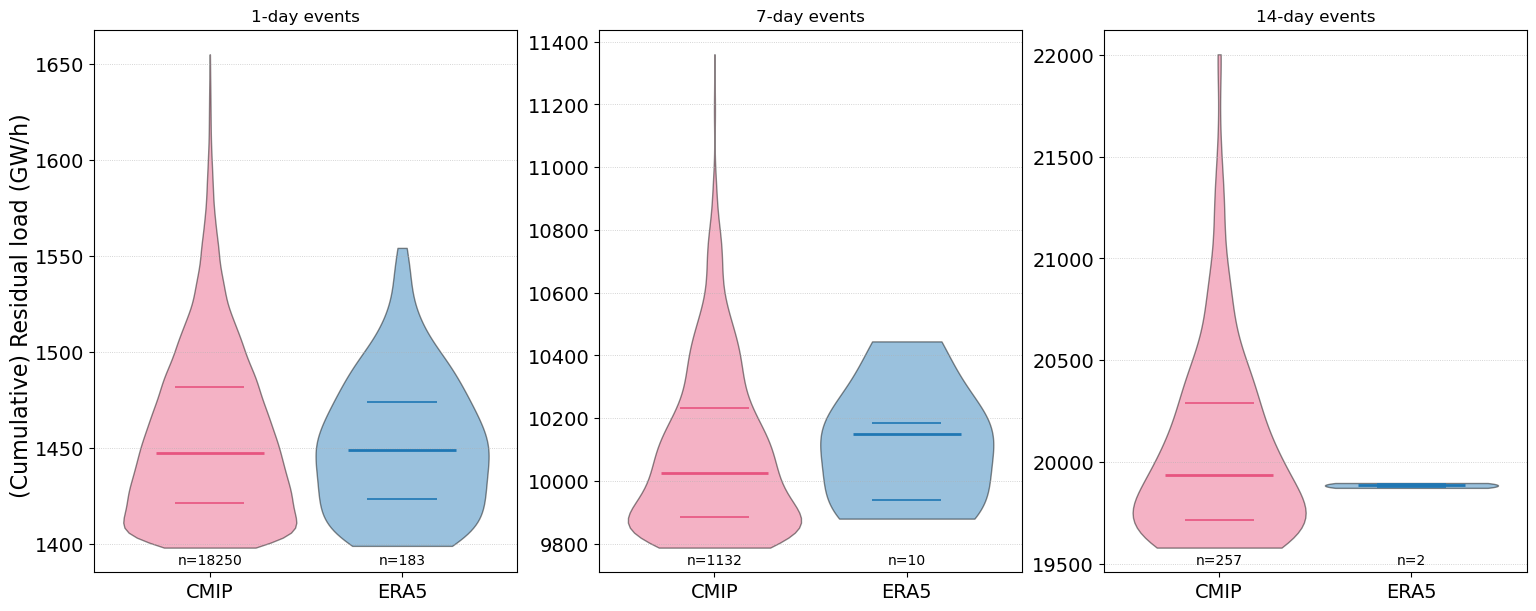

(<Figure size 1500x600 with 3 Axes>,
 array([<Axes: title={'center': '1-day events'}>,
        <Axes: title={'center': '7-day events'}>,
        <Axes: title={'center': '14-day events'}>], dtype=object))

In [41]:


def plot_violin_triplet(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    outpath=None,
    colors=None,
    figsize=(15, 6),
    title_suffix="",
):
    """
    Create a 3-panel figure with paired violins (CMIP vs ERA5) for
    1-day, 7-day and 14-day events.

    Parameters
    ----------
    cmip_1, era_1, cmip_7, era_7, cmip_14, era_14 : array-like
        1D arrays or pandas Series containing the 'RL_cumulative' values
        for CMIP and ERA5 for each event duration.
    outpath : str or None
        If provided, save the figure to this path (PNG). If None, no file is saved.
    colors : list-like of two color strings
        [cmip_color, era_color]. Default: ['#e75480', '#1f77b4'] (pink, blue).
    figsize : tuple
        Figure size passed to plt.subplots.
    title_suffix : str
        Optional string appended to each subplot title.

    Returns
    -------
    fig, axes
        The matplotlib figure and axes for further customization.
    """

    colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue

    datasets = [
        (cmip_1, era_1),
        (cmip_7, era_7),
        (cmip_14, era_14),
    ]
    titles = [f"1-day events {title_suffix}".strip(),
              f"7-day events {title_suffix}".strip(),
              f"14-day events {title_suffix}".strip()]

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=False, constrained_layout=True)

    for ax, (cmip, era), title in zip(axes, datasets, titles):

        # build violinplot: positions 1 (CMIP) and 2 (ERA)
        parts = ax.violinplot(dataset=[cmip, era], positions=[1, 2], vert=True,
                              widths=0.9, showextrema=False, showmedians=False)

        # style violin bodies
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # compute summary stats
        medians = [np.median(cmip) if cmip.size else np.nan,
                   np.median(era) if era.size else np.nan]
        q1 = [np.percentile(cmip, 25) if cmip.size else np.nan,
              np.percentile(era, 25) if era.size else np.nan]
        q3 = [np.percentile(cmip, 75) if cmip.size else np.nan,
              np.percentile(era, 75) if era.size else np.nan]
        mins = [np.min(cmip) if cmip.size else np.nan,
                np.min(era) if era.size else np.nan]
        maxs = [np.max(cmip) if cmip.size else np.nan,
                np.max(era) if era.size else np.nan]

        # Draw median and quartiles and small min/max markers
        for i, pos in enumerate([1, 2]):
            # median
            if not np.isnan(medians[i]):
                ax.hlines(medians[i], pos - 0.28, pos + 0.28, color=colors[i], linewidth=2.0)
            # quartiles
            if not np.isnan(q1[i]) and not np.isnan(q3[i]):
                ax.hlines(q1[i], pos - 0.18, pos + 0.18, color=colors[i], linewidth=1.2)
                ax.hlines(q3[i], pos - 0.18, pos + 0.18, color=colors[i], linewidth=1.2)
            # min/max ticks (as short vertical lines)
            if not np.isnan(mins[i]):
                ax.vlines(pos - 0.08, mins[i], mins[i], color=colors[i], linewidth=2.0)
            if not np.isnan(maxs[i]):
                ax.vlines(pos + 0.08, maxs[i], maxs[i], color=colors[i], linewidth=2.0)

            # annotate sample size above each violin
            sample_n = cmip.size if i == 0 else era.size
            # place annotation just above top of axis range (we'll adjust later once y-limits set)
            ax.text(pos, 0.01, f"n={sample_n}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=10, color='black')

        # x ticks
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['CMIP', 'ERA5'], rotation=0)
        ax.set_title(title, fontsize=12)
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)
        ax.set_xlim(0.4, 2.6)

    # Shared y-label on the left for clarity
    fig.text(-0.014, 0.5, '(Cumulative) Residual load (GW/h)', va='center', rotation='vertical', fontsize=16)

    # # Legend in top center
    # legend_handles = [Patch(facecolor=colors[0], edgecolor='k', alpha=0.45, label='CMIP'),
    #                   Patch(facecolor=colors[1], edgecolor='k', alpha=0.45, label='ERA5')]
    # fig.legend(handles=legend_handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.1))

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes

# ---------------------------
# Example usage (uncomment and replace with your actual arrays/Series):
#
plot_violin_triplet(
    cmip_1 = LEE_dat['RL_cumulative'],
    era_1  = LEE_dat_ERA5['RL_cumulative'],
    cmip_7 = LEE_7['RL_cumulative'],
    era_7  = LEE_7_ERA5['RL_cumulative'],
    cmip_14= LEE_14['RL_cumulative'],
    era_14 = LEE_14_ERA5['RL_cumulative'])
#
# ---------------------------


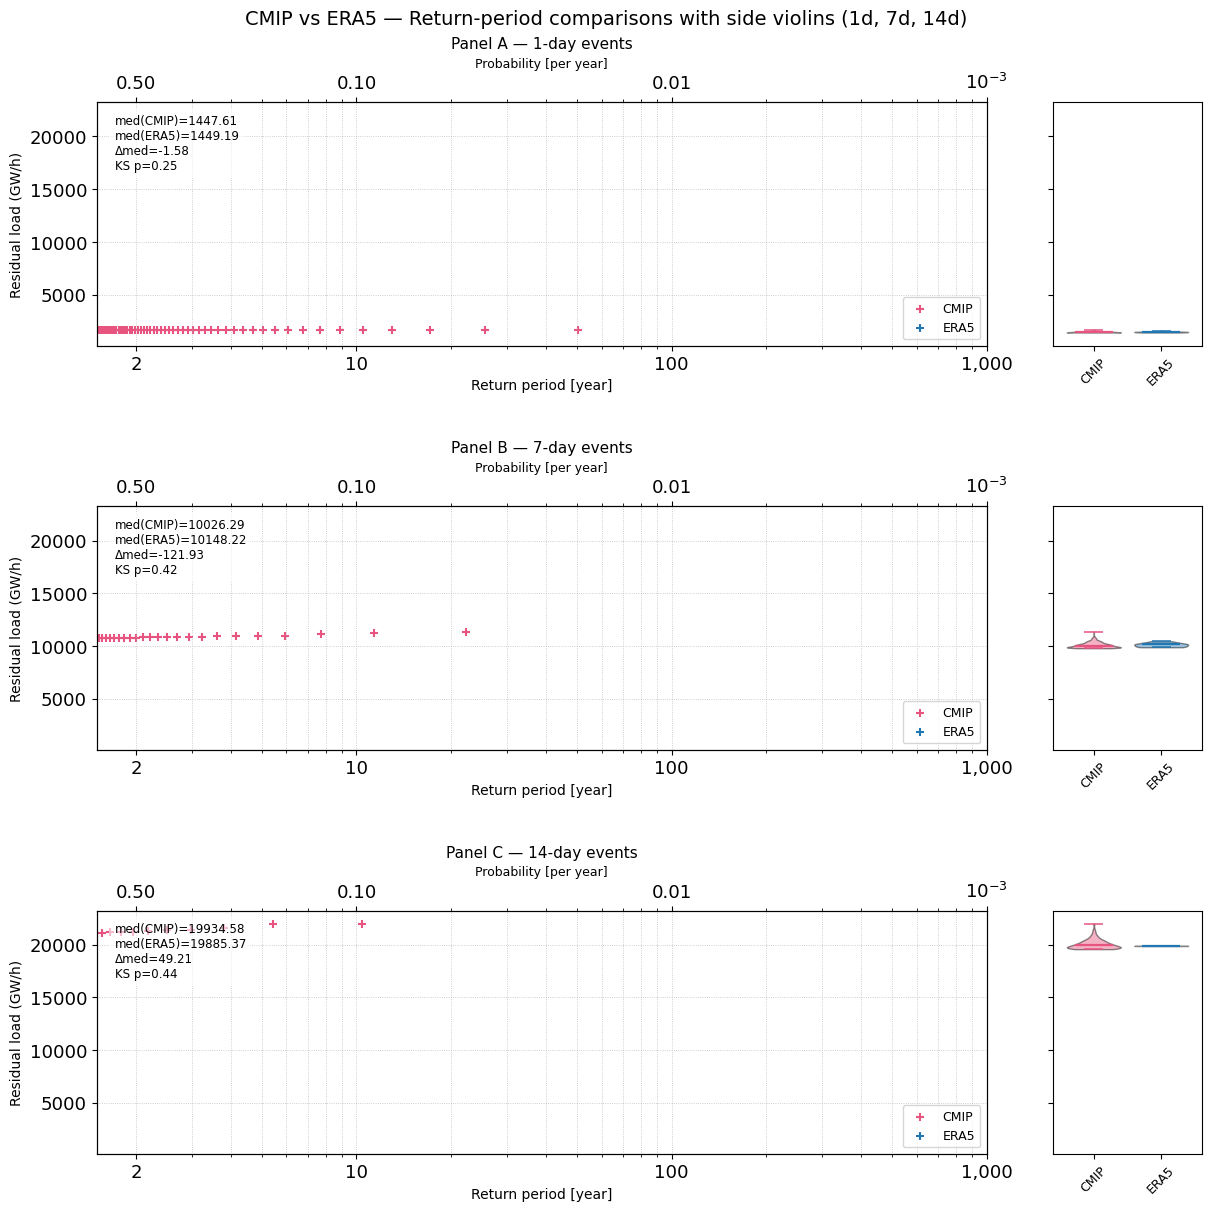

In [ ]:


# --- Inputs (your variables) ---
# 1-day
# LEE_dat['RL_cumulative']
# LEE_dat_ERA5['RL_cumulative']
# 7-day
# LEE_7['RL_cumulative']
# LEE_7_ERA5['RL_cumulative']
# 14-day
# LEE_14['RL_cumulative']
# LEE_14_ERA5['RL_cumulative']

# ---------- plotting routine ----------
colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue
days_per_year = 365.0
max_rp = 1e3
min_rp = 1.0

def to_numpy_dropna(series_like):
    """Accept pandas Series or numpy array; return 1D numpy array with NaNs removed."""
    if isinstance(series_like, (pd.Series, pd.DataFrame)):
        vals = series_like.values.ravel()
    else:
        vals = np.asarray(series_like).ravel()
    vals = vals[~np.isnan(vals)]
    return vals

def empirical_exceedance(values):
    """Return sorted values and per-sample exceedance probability (period basis)."""
    vals = np.sort(values)
    n = len(vals)
    if n == 0:
        return np.array([]), np.array([])
    # plotting-friendly empirical exceedance: 1 - rank/(n+1)
    exceed_prob = 1.0 - np.arange(1, n + 1) / (n + 1)
    return vals, exceed_prob

def rp_from_period_exceedance(exceed_prob_period, duration_days):
    """Convert per-period exceedance -> per-year return period (years)."""
    if len(exceed_prob_period) == 0:
        return np.array([])
    periods_per_year = days_per_year / float(duration_days)
    # per-year exceedance prob:
    p_year = 1.0 - (1.0 - exceed_prob_period) ** periods_per_year
    # avoid division by zero
    rp = np.where(p_year > 0, 1.0 / p_year, np.inf)
    return rp

def plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days, title_label):
    # convert to numpy
    cmip = to_numpy_dropna(cmip_arr)
    era  = to_numpy_dropna(era_arr)

    # empirical survival / exceedance (period basis)
    era_vals, era_p_period = empirical_exceedance(era)
    cmip_vals, cmip_p_period = empirical_exceedance(cmip)

    # convert to return periods (years) for plotting on x-axis
    era_rp = rp_from_period_exceedance(era_p_period, duration_days)
    cmip_rp = rp_from_period_exceedance(cmip_p_period, duration_days)

    # masks for readability: keep only rp within [min_rp, max_rp]
    era_mask  = np.isfinite(era_rp)  & (era_rp <= max_rp)  & (era_rp >= min_rp)
    cmip_mask = np.isfinite(cmip_rp) & (cmip_rp <= max_rp) & (cmip_rp >= min_rp)

    era_vals_plot, era_rp_plot   = era_vals[era_mask], era_rp[era_mask]
    cmip_vals_plot, cmip_rp_plot = cmip_vals[cmip_mask], cmip_rp[cmip_mask]

    # scatter points (main axis)
    ax_main.scatter(cmip_rp_plot, cmip_vals_plot, marker='+', s=28, color=colors[0], label='CMIP')
    ax_main.scatter(era_rp_plot, era_vals_plot, marker='+', s=28, color=colors[1], label='ERA5')

    ax_main.set_xscale('log')
    ax_main.set_xlim(1.5, max_rp)
    ax_main.set_xlabel('Return period [year]', fontsize=10)
    ax_main.set_ylabel('Residual load (GW/h)', fontsize=10)
    ax_main.grid(which='both', linestyle=':', linewidth=0.6, alpha=0.8)

    # xticks and top probability axis
    bottom_ticks = [2, 10, 100, 1000]
    ax_main.set_xticks(bottom_ticks)
    ax_main.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    top = ax_main.twiny()
    top.set_xscale('log')
    top.set_xlim(ax_main.get_xlim())
    top.set_xticks(bottom_ticks)
    # probability per year = 1/RP
    top_labels = [f'{1.0/rp:.0e}' for rp in bottom_ticks]
    # nicer: show as 10^{-k} where applicable
    top_labels_pretty = []
    for rp in bottom_ticks:
        prob = 1.0 / rp
        if prob < 1e-2:
            # show scientific style 10^{-k}
            k = int(np.round(-np.log10(prob)))
            top_labels_pretty.append(r'$10^{-%d}$' % k)
        else:
            top_labels_pretty.append(f'{prob:.2f}')
    top.set_xticklabels(top_labels_pretty)
    top.set_xlabel('Probability [per year]', fontsize=9)

    # legend + title
    ax_main.legend(loc='lower right', fontsize=9)
    ax_main.set_title(f'{title_label} — {duration_days}-day events', fontsize=11)

    # violin on right (narrow)
    data_for_violin = [cmip, era]
    positions = [1.0, 2.0]
    parts = ax_violin.violinplot(dataset=data_for_violin, positions=positions, vert=True,
                                 widths=0.8, showextrema=False, showmedians=False)

    # draw medians & min/max
    medians = [np.median(cmip) if cmip.size else np.nan, np.median(era) if era.size else np.nan]
    maxes   = [np.max(cmip) if cmip.size else np.nan,     np.max(era) if era.size else np.nan]
    mins    = [np.min(cmip) if cmip.size else np.nan,     np.min(era) if era.size else np.nan]

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.45)
        # median line
        ax_violin.hlines(medians[i], positions[i] - 0.28, positions[i] + 0.28, color=colors[i], linewidth=1.6)
        # min/max short lines
        ax_violin.hlines(maxes[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)
        ax_violin.hlines(mins[i],  positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)

    ax_violin.set_xticks(positions)
    ax_violin.set_xticklabels(['CMIP', 'ERA5'], rotation=45, fontsize=9)
    ax_violin.yaxis.set_tick_params(labelleft=False)  # hide duplicate y tick labels
    ax_violin.set_xlim(0.4, 2.6)
    ax_violin.set_ylim(ax_main.get_ylim())

    # annotate simple stats (median difference, KS p-value)
    try:
        ks_stat, ks_p = stats.ks_2samp(cmip, era, alternative='two-sided', mode='asymp')
    except Exception:
        ks_stat, ks_p = np.nan, np.nan
    med_diff = medians[0] - medians[1]
    txt = f'med(CMIP)={medians[0]:.2f}\nmed(ERA5)={medians[1]:.2f}\nΔmed={med_diff:.2f}\nKS p={ks_p:.2g}'
    ax_main.text(0.02, 0.95, txt, transform=ax_main.transAxes, fontsize=8.5,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# ---------- assemble figure ----------
def make_three_rp_violins(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    figsize=(12, 12)
):
    # compute a global y-limits across all arrays for consistent comparison
    all_vals = np.concatenate([
        to_numpy_dropna(cmip_1), to_numpy_dropna(era_1),
        to_numpy_dropna(cmip_7), to_numpy_dropna(era_7),
        to_numpy_dropna(cmip_14), to_numpy_dropna(era_14)
    ])
    if all_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
        pad = 0.06 * (vmax - vmin if vmax > vmin else max(1.0, abs(vmax)))
        vmin -= pad
        vmax += pad

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    # 3 rows x 2 cols (left=main, right=violin), use GridSpec
    gs = fig.add_gridspec(3, 2, width_ratios=[6, 1], hspace=0.12, wspace=0.06)

    datasets = [
        (cmip_1, era_1, 1, 'Panel A'),
        (cmip_7, era_7, 7, 'Panel B'),
        (cmip_14, era_14, 14, 'Panel C'),
    ]

    for row, (cmip_arr, era_arr, days, label) in enumerate(datasets):
        ax_main = fig.add_subplot(gs[row, 0])
        ax_violin = fig.add_subplot(gs[row, 1], sharey=ax_main)
        # set same ylims for each subplot
        ax_main.set_ylim(vmin, vmax)
        plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days=days, title_label=label)

    # overall title
    fig.suptitle('CMIP vs ERA5 — Return-period comparisons with side violins (1d, 7d, 14d)', fontsize=14)
    plt.show()
    return fig

# ---------- Example call using your objects ----------
# Uncomment and run (replace the variable names with your actual objects if different)
fig = make_three_rp_violins(
    LEE_dat['RL_cumulative'], LEE_dat_ERA5['RL_cumulative'],
    LEE_7['RL_cumulative'], LEE_7_ERA5['RL_cumulative'],
    LEE_14['RL_cumulative'], LEE_14_ERA5['RL_cumulative'],
)
fig.savefig('CMIP_ERA5_RP_violins_1_7_14d.png', dpi=300, bbox_inches='tight')


/tmp/ipykernel_915050/2126613704.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)
/tmp/ipykernel_915050/2126613704.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)
/tmp/ipykernel_915050/2126613704.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_main.set_xlim(0, max_rp)


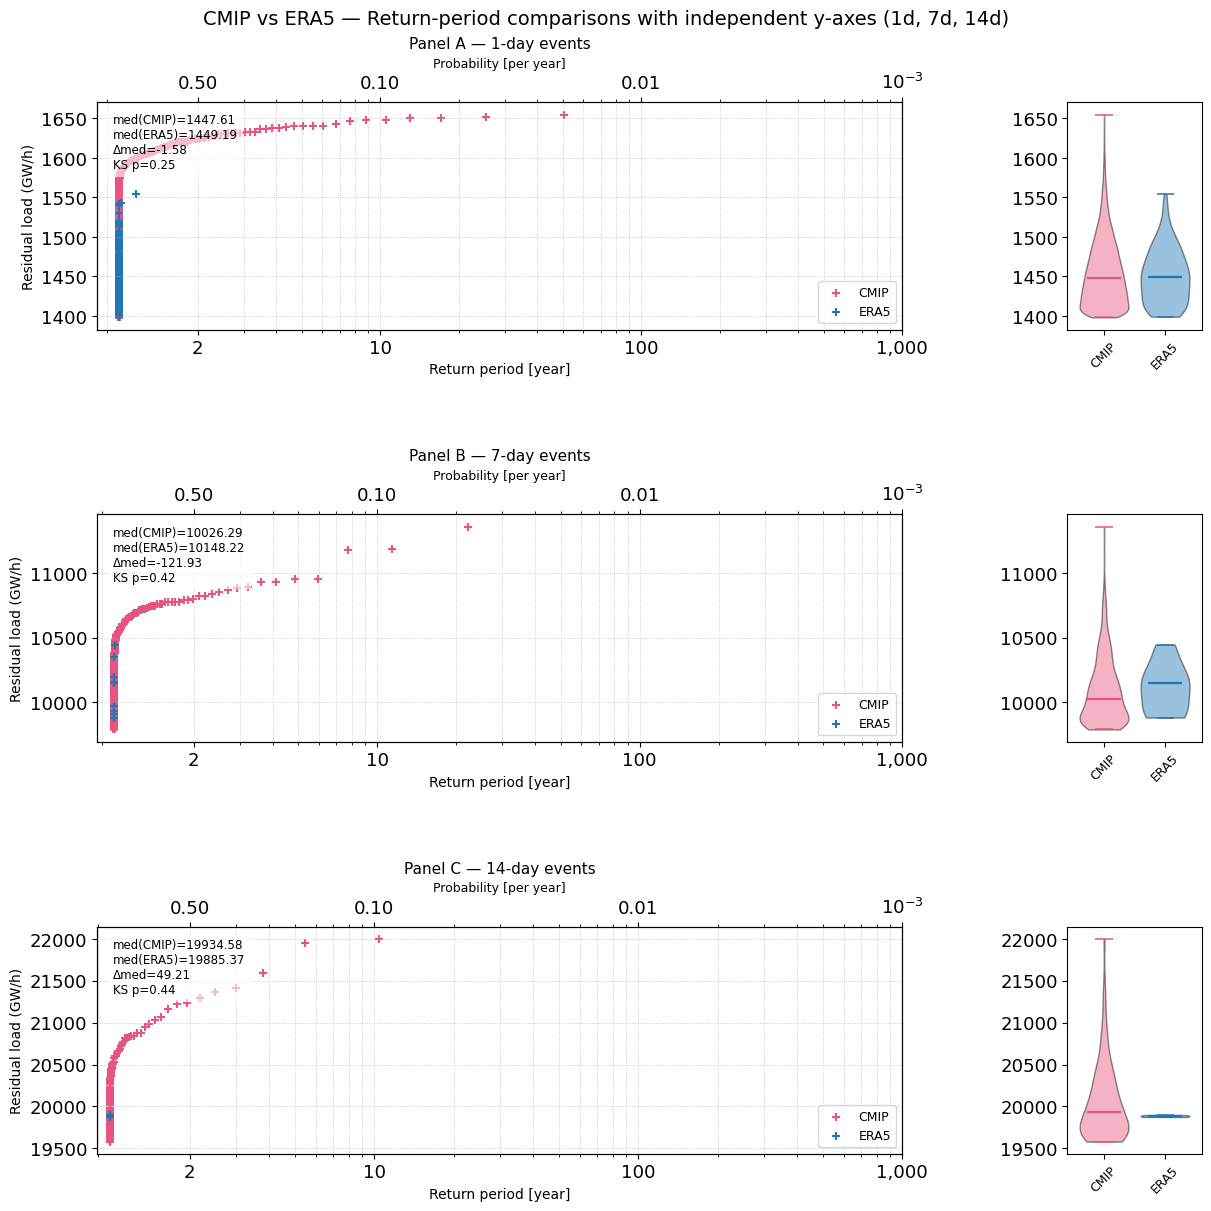

In [ ]:

# ---------- helper functions ----------
colors = ['#e75480', '#1f77b4']  # CMIP pink, ERA5 blue
days_per_year = 365.0
max_rp = 1e3
min_rp = 1.0

def to_numpy_dropna(series_like):
    if isinstance(series_like, (pd.Series, pd.DataFrame)):
        vals = series_like.values.ravel()
    else:
        vals = np.asarray(series_like).ravel()
    vals = vals[~np.isnan(vals)]
    return vals

def empirical_exceedance(values):
    vals = np.sort(values)
    n = len(vals)
    if n == 0:
        return np.array([]), np.array([])
    exceed_prob = 1.0 - np.arange(1, n + 1) / (n + 1)
    return vals, exceed_prob

def rp_from_period_exceedance(exceed_prob_period, duration_days):
    if len(exceed_prob_period) == 0:
        return np.array([])
    periods_per_year = days_per_year / float(duration_days)
    p_year = 1.0 - (1.0 - exceed_prob_period) ** periods_per_year
    rp = np.where(p_year > 0, 1.0 / p_year, np.inf)
    return rp

def plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days, title_label):
    cmip = to_numpy_dropna(cmip_arr)
    era  = to_numpy_dropna(era_arr)

    era_vals, era_p_period = empirical_exceedance(era)
    cmip_vals, cmip_p_period = empirical_exceedance(cmip)

    era_rp = rp_from_period_exceedance(era_p_period, duration_days)
    cmip_rp = rp_from_period_exceedance(cmip_p_period, duration_days)

    era_mask  = np.isfinite(era_rp)  & (era_rp <= max_rp)  & (era_rp >= min_rp)
    cmip_mask = np.isfinite(cmip_rp) & (cmip_rp <= max_rp) & (cmip_rp >= min_rp)

    era_vals_plot, era_rp_plot   = era_vals[era_mask], era_rp[era_mask]
    cmip_vals_plot, cmip_rp_plot = cmip_vals[cmip_mask], cmip_rp[cmip_mask]

    # scatter points
    ax_main.scatter(cmip_rp_plot, cmip_vals_plot, marker='+', s=28, color=colors[0], label='CMIP')
    ax_main.scatter(era_rp_plot, era_vals_plot, marker='+', s=28, color=colors[1], label='ERA5')

    ax_main.set_xscale('log')
    ax_main.set_xlim(0, max_rp)
    ax_main.set_xlabel('Return period [year]', fontsize=10)
    ax_main.set_ylabel('Residual load (GW/h)', fontsize=10)
    ax_main.grid(which='both', linestyle=':', linewidth=0.6, alpha=0.8)

    bottom_ticks = [2, 10, 100, 1000]
    ax_main.set_xticks(bottom_ticks)
    ax_main.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    top = ax_main.twiny()
    top.set_xscale('log')
    top.set_xlim(ax_main.get_xlim())
    top.set_xticks(bottom_ticks)
    # nicer labels for top axis
    top_labels_pretty = []
    for rp in bottom_ticks:
        prob = 1.0 / rp
        if prob < 1e-2:
            k = int(np.round(-np.log10(prob)))
            top_labels_pretty.append(r'$10^{-%d}$' % k)
        else:
            top_labels_pretty.append(f'{prob:.2f}')
    top.set_xticklabels(top_labels_pretty)
    top.set_xlabel('Probability [per year]', fontsize=9)

    ax_main.legend(loc='lower right', fontsize=9)
    ax_main.set_title(f'{title_label} — {duration_days}-day events', fontsize=11)

    # --- set y-limits PER ROW (so each row has own y-axis) ---
    # compute y-limits from the two arrays for this row
    combined = np.concatenate([cmip, era]) if (cmip.size + era.size) > 0 else np.array([0.0])
    vmin = np.nanmin(combined)
    vmax = np.nanmax(combined)
    if vmin == vmax:
        # small fudge to avoid zero-range
        vmin -= 0.5 * abs(vmin) + 0.5
        vmax += 0.5 * abs(vmax) + 0.5
    pad = 0.06 * (vmax - vmin)
    ax_main.set_ylim(vmin - pad, vmax + pad)

    # violin (do NOT share y with other rows)
    data_for_violin = [cmip, era]
    positions = [1.0, 2.0]
    parts = ax_violin.violinplot(dataset=data_for_violin, positions=positions, vert=True,
                                 widths=0.8, showextrema=False, showmedians=False)

    medians = [np.median(cmip) if cmip.size else np.nan, np.median(era) if era.size else np.nan]
    maxes   = [np.max(cmip) if cmip.size else np.nan,     np.max(era) if era.size else np.nan]
    mins    = [np.min(cmip) if cmip.size else np.nan,     np.min(era) if era.size else np.nan]

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.45)
        ax_violin.hlines(medians[i], positions[i] - 0.28, positions[i] + 0.28, color=colors[i], linewidth=1.6)
        ax_violin.hlines(maxes[i], positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)
        ax_violin.hlines(mins[i],  positions[i] - 0.14, positions[i] + 0.14, color=colors[i], linewidth=1.1)

    ax_violin.set_xticks(positions)
    ax_violin.set_xticklabels(['CMIP', 'ERA5'], rotation=45, fontsize=9)
    # do NOT hide violin y ticks now — each row has its own y-axis so keep them visible for readability
    ax_violin.set_xlim(0.4, 2.6)
    # set violin y-limits to match the main axis for the same row so the shapes align vertically
    ax_violin.set_ylim(ax_main.get_ylim())

    # annotate statistics
    try:
        ks_stat, ks_p = stats.ks_2samp(cmip, era, alternative='two-sided', mode='asymp')
    except Exception:
        ks_stat, ks_p = np.nan, np.nan
    med_diff = medians[0] - medians[1]
    txt = f'med(CMIP)={medians[0]:.2f}\nmed(ERA5)={medians[1]:.2f}\nΔmed={med_diff:.2f}\nKS p={ks_p:.2g}'
    ax_main.text(0.02, 0.95, txt, transform=ax_main.transAxes, fontsize=8.5,
                 verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# ---------- assemble figure with independent y-axes per row ----------
def make_three_rp_violins_independent_y(
    cmip_1, era_1,
    cmip_7, era_7,
    cmip_14, era_14,
    figsize=(12, 12)
):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(3, 2, width_ratios=[6, 1], hspace=0.18, wspace=0.12)

    datasets = [
        (cmip_1, era_1, 1, 'Panel A'),
        (cmip_7, era_7, 7, 'Panel B'),
        (cmip_14, era_14, 14, 'Panel C'),
    ]

    for row, (cmip_arr, era_arr, days, label) in enumerate(datasets):
        ax_main = fig.add_subplot(gs[row, 0])
        ax_violin = fig.add_subplot(gs[row, 1])  # no sharey
        plot_rp_and_violin(ax_main, ax_violin, cmip_arr, era_arr, duration_days=days, title_label=label)

    fig.suptitle('CMIP vs ERA5 — Return-period comparisons with independent y-axes (1d, 7d, 14d)', fontsize=14)
    plt.show()
    return fig

# ---------- Example call (uncomment to run) ----------
fig = make_three_rp_violins_independent_y(
    LEE_dat['RL_cumulative'], LEE_dat_ERA5['RL_cumulative'],
    LEE_7['RL_cumulative'], LEE_7_ERA5['RL_cumulative'],
    LEE_14['RL_cumulative'], LEE_14_ERA5['RL_cumulative'],
)
# fig.savefig('CMIP_ERA5_RP_violins_1_7_14d_indepY.png', dpi=300, bbox_inches='tight')


----

## Calculation of SRLI (OLD)

In [ ]:


def compute_srli(data_array, eps=1e-4): #1/(2*180180)
    """
    Compute the SRLI (Standardised Residual Load Index) over the full dataset,
    while keeping the shape and metadata of the input xarray DataArray.

    Parameters:
    - data_array (xarray.DataArray): input residual load (shape: ESM_run x time)

    Returns:
    - srli (xarray.DataArray): same shape as input, with SRLI values
    """
    # Compute ECDF ranks using Dask
    def ecdf_rank(values):
        # Sort the values
        sorted_vals = np.sort(values)
        # Use searchsorted to get the ECDF
        ranks = np.searchsorted(sorted_vals, values, side="right")
        ecdf_vals = (ranks + 1) / (len(values) + 1)
        return np.clip(ecdf_vals, eps, 1 - eps)  # avoid 0 and 1
    
    
    # Compute ECDF on full dataset (across all dimensions)
    ecdf = data_array.copy(data=da.map_blocks(
        lambda block: ecdf_rank(block.flatten()).reshape(block.shape),
        data_array.data,
        dtype=float
    ))

    # Apply inverse normal CDF (probit function)
    srli = xr.apply_ufunc(
        norm.ppf,
        ecdf,
        dask='parallelized',
        output_dtypes=[float]
    )

    # Rename the result
    srli.name = "SRLI"

    return srli


In [89]:
srli_tst = compute_srli(RL)

In [ ]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool = xr.where(srli_tst.values > 1.64, True, False)

# Find contiguous regions of exceed_bool = True
events, n_events = ndimage.label(exceed_bool)

In [74]:
events

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

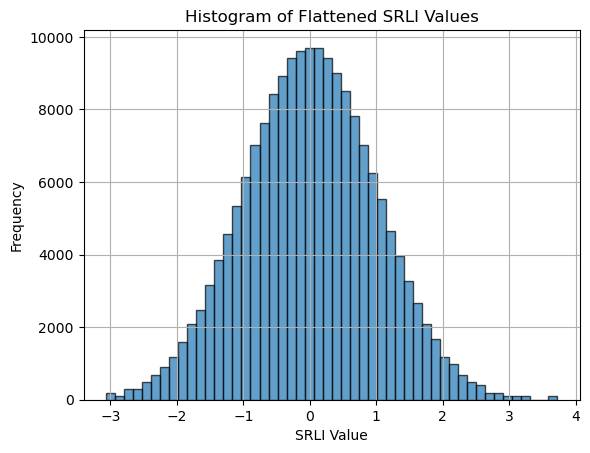

In [ ]:

# Flatten the SRLI values and create a histogram
plt.hist(srli_tst.values.flatten(), bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('SRLI Value')
plt.ylabel('Frequency')
plt.title('Histogram of Flattened SRLI Values')
plt.grid(True)
plt.show()

## Old Code

#### SRLI for individual run

In [ ]:


def calculate_srli(residual_load_series):
    """
    Calculate the Standardised Residual Load Index (SRLI) from a series of residual load values.
    
    Parameters:
    - residual_load_series: pd.Series or np.array of residual load values

    Returns:
    - srli_values: np.array of SRLI values
    """
    # Ensure data is a numpy array
    data = np.array(residual_load_series)
    
    # Rank the data to calculate the empirical CDF
    sorted_data = np.sort(data)
    ranks = np.searchsorted(sorted_data, data, side='right')
    empirical_cdf = (ranks + 1) / (len(data) + 1)

    # Apply the inverse of the standard normal CDF (probit)
    srli_values = norm.ppf(empirical_cdf)
    
    return srli_values